In [12]:
# ============================================================
# Cell 0. 라이브러리 임포트 및 환경 설정
#
# [작업 개요]
# 전체 분석에 필요한 라이브러리를 한 곳에서 관리
# 경로 설정도 여기서 고정 → 이후 셀에서 경로 하드코딩 없음
#
# [논문 근거]
# 김종윤(2019) p.28 "모형 개발을 위한 데이터 탐색 및 전처리"
# NICE디앤비 기업신용등급 공시 - 평가모형 개발/검증 절차
#
# [환경]
# - 가상환경 : C:\ITStudy\seminar_02\venv
# - 노트북   : C:\ITStudy\seminar_02\CSS.ipynb
# - 데이터   : C:\ITStudy\seminar_02\american_bankruptcy.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Windows 환경) ──────────────────────────
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# ── 경로 설정 ───────────────────────────────────────────────
DATA_PATH = r'C:\ITStudy\seminar_02\american_bankruptcy.csv'

# ── 분석 기준 설정 ──────────────────────────────────────────
# [논문 p.58~59 근거]
# 논문은 단일 기준시점 기반 분할을 사용했으나,
# 본 연구 데이터는 부도 기업이 관측 기간 내내 failed 라벨을 유지하며
# 연도별로 고르게 분포되지 않는 구조임
# → 시간 기준 분할 시 OOT 부도 샘플이 극소(93행)로 검증 불가
# → 기업 단위 랜덤 분할 적용
#
# Train    : 전체 기업의 70% → 모형 개발
# Hold-Out : 전체 기업의 15% → 중간 검증
# OOT      : 전체 기업의 15% → PSI + 변별력 최종 검증
TRAIN_RATIO   = 0.70
HOLDOUT_RATIO = 0.15
RANDOM_SEED   = 42

# ── 원본 변수 리스트 ────────────────────────────────────────
# american_bankruptcy.csv 기준 재무변수 18개
FEATURE_COLS = [f'X{i}' for i in range(1, 19)]  # X1 ~ X18

# ── 타깃 컬럼명 ─────────────────────────────────────────────
TARGET_COL = 'target'  # 전처리 후 생성 (failed=1, alive=0)

# ── 출력 ────────────────────────────────────────────────────
print("=" * 55)
print("  환경 설정 완료")
print("=" * 55)
print(f"  데이터 경로  : {DATA_PATH}")
print(f"  원본 변수 수 : {len(FEATURE_COLS)}개 ({FEATURE_COLS[0]} ~ {FEATURE_COLS[-1]})")
print(f"  분할 방식    : 기업 단위 랜덤 분할")
print(f"  Train        : 전체 기업의 {int(TRAIN_RATIO*100)}%")
print(f"  Hold-Out     : 전체 기업의 {int(HOLDOUT_RATIO*100)}%")
print(f"  OOT          : 전체 기업의 {int((1-TRAIN_RATIO-HOLDOUT_RATIO)*100)}%")
print(f"  Random Seed  : {RANDOM_SEED}")
print(f"  타깃 정의    : failed=1 (불량), alive=0 (우량)")

  환경 설정 완료
  데이터 경로  : C:\ITStudy\seminar_02\american_bankruptcy.csv
  원본 변수 수 : 18개 (X1 ~ X18)
  분할 방식    : 기업 단위 랜덤 분할
  Train        : 전체 기업의 70%
  Hold-Out     : 전체 기업의 15%
  OOT          : 전체 기업의 15%
  Random Seed  : 42
  타깃 정의    : failed=1 (불량), alive=0 (우량)


In [15]:
# ============================================================
# Cell 1. 데이터 로드 및 기본 EDA
#
# [작업 개요]
# 데이터 로드 후 기본 구조 파악
# 결측치, 타깃 분포, 기업별 관측 연도 수 확인
#
# [논문 근거 - 김종윤(2019)]
# p.26 "개발모집단은 충분한 규모가 확보되어야 하고
#       불량을 관찰할 수 있는 일정기간 확보를 전제로
#       최신성이 보장되어야 한다"
# ============================================================

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

# ── [1] 기본 정보 ────────────────────────────────────────────
print("=" * 55)
print("  [1] 데이터 기본 정보")
print("=" * 55)
print(f"  전체 행 수        : {len(df):,}행")
print(f"  전체 컬럼 수      : {df.shape[1]}개")
print(f"  기업 수           : {df['company_name'].nunique():,}개")
print(f"  연도 범위         : {df['year'].min()} ~ {df['year'].max()}")
print(f"  재무변수 수       : {len(FEATURE_COLS)}개 (X1 ~ X18)")
missing = df.isnull().sum().sum()
print(f"  결측치 총계       : {missing}개",
      "(없음)" if missing == 0 else "← 처리 필요")
print()

# ── [2] 타깃 분포 (행 단위) ──────────────────────────────────
print("=" * 55)
print("  [2] 타깃 분포 - 행 단위 / 기업 단위")
print("=" * 55)
for label, cnt in df['status_label'].value_counts().items():
    print(f"  행단위 {label:<10} : {cnt:>7,}행  ({cnt/len(df)*100:.2f}%)")
print()

company_target = df.groupby('company_name')['status_label'].first()
total_co = len(company_target)
for label, cnt in company_target.value_counts().items():
    print(f"  기업단위 {label:<10} : {cnt:>5,}개  ({cnt/total_co*100:.2f}%)")
print(f"  기업 단위 부도율  : {company_target.value_counts().get('failed',0)/total_co*100:.2f}%")
print()

# ── [3] 기업별 관측 연도 수 ──────────────────────────────────
print("=" * 55)
print("  [3] 기업별 관측 연도 수 분포")
print("=" * 55)
obs_count = df.groupby('company_name')['year'].count()
print(f"  평균 : {obs_count.mean():.1f}년 | "
      f"최소 : {obs_count.min()}년 | "
      f"최대 : {obs_count.max()}년")
print()
for label, cnt in pd.cut(
    obs_count,
    bins=[0,1,2,3,5,10,20],
    labels=['1년','2년','3년','4~5년','6~10년','11년+']
).value_counts().sort_index().items():
    print(f"  {label:<8} : {cnt:>6,}개  ({cnt/total_co*100:.1f}%)")
print()
print("  ※ 3년 미만 기업 → 시계열 파생변수 NaN 처리 예정")

  [1] 데이터 기본 정보
  전체 행 수        : 78,682행
  전체 컬럼 수      : 21개
  기업 수           : 8,971개
  연도 범위         : 1999 ~ 2018
  재무변수 수       : 18개 (X1 ~ X18)
  결측치 총계       : 0개 (없음)

  [2] 타깃 분포 - 행 단위 / 기업 단위
  행단위 alive      :  73,462행  (93.37%)
  행단위 failed     :   5,220행  (6.63%)

  기업단위 alive      : 8,362개  (93.21%)
  기업단위 failed     :   609개  (6.79%)
  기업 단위 부도율  : 6.79%

  [3] 기업별 관측 연도 수 분포
  평균 : 8.8년 | 최소 : 1년 | 최대 : 20년

  1년       :    755개  (8.4%)
  2년       :    906개  (10.1%)
  3년       :    756개  (8.4%)
  4~5년     :  1,297개  (14.5%)
  6~10년    :  2,164개  (24.1%)
  11년+     :  3,093개  (34.5%)

  ※ 3년 미만 기업 → 시계열 파생변수 NaN 처리 예정


In [16]:
# ============================================================
# Cell 2. 기업 단위 랜덤 분할
#
# [작업 개요]
# 전체 기업을 Train/Hold-Out/OOT로 분할
# 같은 기업의 모든 연도 행이 동일 구간에 속하도록 설계
# → 기업 간 정보 누수 방지
#
# [논문 근거 - 김종윤(2019)]
# p.31 "Training Sample, Hold-Out Sample,
#       Out-of-Time Sample로 분류한다"
# → 본 연구는 패널 데이터 특성상 기업 단위 분할 적용
#
# [NICE 공시 근거]
# "세그먼트별 우량/불량 각각 최소 500건 이상 확보"
# → 분할 후 부도 기업 수 확인 필수
# ============================================================

company_list = df['company_name'].unique()
np.random.seed(RANDOM_SEED)
shuffled = company_list.copy()
np.random.shuffle(shuffled)

n = len(shuffled)
train_companies   = shuffled[:int(n * TRAIN_RATIO)]
holdout_companies = shuffled[int(n * TRAIN_RATIO)
                             :int(n * (TRAIN_RATIO + HOLDOUT_RATIO))]
oot_companies     = shuffled[int(n * (TRAIN_RATIO + HOLDOUT_RATIO)):]

# 기업명 → 구간 매핑 딕셔너리 (이후 셀에서 계속 사용)
split_map = {}
for c in train_companies:   split_map[c] = 'train'
for c in holdout_companies: split_map[c] = 'holdout'
for c in oot_companies:     split_map[c] = 'oot'

# ── 결과 출력 ────────────────────────────────────────────────
print("=" * 55)
print("  기업 단위 랜덤 분할 결과")
print("=" * 55)
print(f"  {'구간':<12} | {'기업':>6} | {'부도':>5} | {'우량':>6} | {'부도율':>7}")
print("  " + "-" * 45)
for label, cos in [
    ('Train',    train_companies),
    ('Hold-Out', holdout_companies),
    ('OOT',      oot_companies),
]:
    total  = len(cos)
    failed = (company_target[cos] == 'failed').sum()
    alive  = (company_target[cos] == 'alive').sum()
    print(f"  {label:<12} | {total:>6,} | {failed:>5,} | {alive:>6,} | {failed/total*100:>6.1f}%")

print()
print("  ※ 같은 기업의 모든 연도 행이 동일 구간에 속함")
print("  ※ PSI : Train vs OOT 점수 분포 비교로 계산 예정")

  기업 단위 랜덤 분할 결과
  구간           |     기업 |    부도 |     우량 |     부도율
  ---------------------------------------------
  Train        |  6,279 |   422 |  5,857 |    6.7%
  Hold-Out     |  1,346 |    97 |  1,249 |    7.2%
  OOT          |  1,346 |    90 |  1,256 |    6.7%

  ※ 같은 기업의 모든 연도 행이 동일 구간에 속함
  ※ PSI : Train vs OOT 점수 분포 비교로 계산 예정


In [20]:
# ============================================================
# Cell 3. 전체 파생변수 생성
#
# [작업 개요]
# 1. 시계열 파생변수 (22종 × 18개 = 396개)
# 2. 2개 변수 조합 파생변수 (나누기 306개 + 빼기 153개)
# 3. 3개 변수 조합 파생변수 (재무적 의미 기반 수동 정의)
#    - 재무비율 조합, Altman Z-score 구성요소
#    - 듀퐁 분석 기반 곱하기 조합 포함
# → 전체 약 900개+ 후보 변수 생성
#
# [핵심 아이디어]
# 절댓값보다 "변화의 방향과 속도", "변수 간 비율"이
# 부도를 더 잘 예측
# 예) 부채/자산 비율이 높고 3년 연속 악화 중이면 부도 가능성 높음
#
# [곱하기 파생변수 설계 원칙]
# 절댓값 × 절댓값 = 단위가 달러² → 재무적 해석 불가
# → 비율 × 비율 형태만 사용 (듀퐁 분석 등)
# 예) ROA × 자산회전율 = (순이익/총자산) × (순매출/총자산)
#
# [논문 근거 - 김종윤(2019)]
# p.60 "약 1,700개의 평가항목을 생성하고 합성하였다"
# p.61 "평가항목 생성 과정에서 업무적 실질적
#       생성 및 활용 가능성을 사전적으로 고려"
#
# [NICE 공시 근거]
# 성장성(변화율), 수익성(이익/매출),
# 안정성(부채/자본), 활동성(회전율),
# 현금흐름(CF/매출) → 파생변수가 이 역할 수행
# ============================================================

# 기업별 연도 순 정렬 (shift/rolling 계산 전 필수)
df = df.sort_values(['company_name', 'year']).reset_index(drop=True)

g = df.groupby('company_name')
df_feat = df.copy()

# ── [1] 시계열 파생변수 생성 ─────────────────────────────────
print("  [1] 시계열 파생변수 생성 중...")

for col in FEATURE_COLS:
    s = g[col]

    # 변화율 (성장성 지표)
    df_feat[f'{col}_pct1'] = s.pct_change(1)
    df_feat[f'{col}_pct2'] = s.pct_change(2)
    df_feat[f'{col}_pct3'] = s.pct_change(3)

    # 절대변화량
    df_feat[f'{col}_diff1'] = s.diff(1)
    df_feat[f'{col}_diff2'] = s.diff(2)

    # 이동평균 (추세 수준)
    df_feat[f'{col}_ma3'] = s.transform(
        lambda x: x.rolling(3, min_periods=3).mean())
    df_feat[f'{col}_ma5'] = s.transform(
        lambda x: x.rolling(5, min_periods=5).mean())

    # 변동성 (불안정성)
    df_feat[f'{col}_std3'] = s.transform(
        lambda x: x.rolling(3, min_periods=3).std())
    df_feat[f'{col}_std5'] = s.transform(
        lambda x: x.rolling(5, min_periods=5).std())

    # 구간 내 최솟값/최댓값
    df_feat[f'{col}_min3'] = s.transform(
        lambda x: x.rolling(3, min_periods=3).min())
    df_feat[f'{col}_max3'] = s.transform(
        lambda x: x.rolling(3, min_periods=3).max())
    df_feat[f'{col}_min5'] = s.transform(
        lambda x: x.rolling(5, min_periods=5).min())
    df_feat[f'{col}_max5'] = s.transform(
        lambda x: x.rolling(5, min_periods=5).max())

    # 가속도 (악화 속도)
    diff1 = s.diff(1)
    df_feat[f'{col}_acc'] = diff1 - diff1.shift(1)

    # 현재값 / 이동평균 (수준 대비 현재 위치)
    ma3 = s.transform(lambda x: x.rolling(3, min_periods=3).mean())
    ma5 = s.transform(lambda x: x.rolling(5, min_periods=5).mean())
    df_feat[f'{col}_ratio_ma3'] = df_feat[col] / ma3.replace(0, np.nan)
    df_feat[f'{col}_ratio_ma5'] = df_feat[col] / ma5.replace(0, np.nan)

    # 연속 하락/상승 여부 (0/1)
    d1 = s.diff(1)
    d2 = s.diff(1).shift(1)
    df_feat[f'{col}_down3'] = ((d1 < 0) & (d2 < 0)).astype(int)
    df_feat[f'{col}_down5'] = (
        (s.diff(1) < 0) & (s.diff(1).shift(1) < 0) &
        (s.diff(1).shift(2) < 0) & (s.diff(1).shift(3) < 0)
    ).astype(int)
    df_feat[f'{col}_up3'] = ((d1 > 0) & (d2 > 0)).astype(int)

    # Lag 변수
    df_feat[f'{col}_lag1'] = s.shift(1)
    df_feat[f'{col}_lag2'] = s.shift(2)
    df_feat[f'{col}_lag3'] = s.shift(3)

ts_cols = [c for c in df_feat.columns if c not in list(df.columns)]
print(f"  완료 → 시계열 파생변수 {len(ts_cols)}개 생성")
print()

# ── [2] 2개 변수 조합 파생변수 ───────────────────────────────
# 나누기 A/B : 비율 지표 (수익성, 안정성, 활동성)
# 빼기 A-B   : 차이 지표 (순운전자본 등)
print("  [2] 2개 변수 조합 파생변수 생성 중...")

div_cols  = []
diff_cols = []

for i, col_a in enumerate(FEATURE_COLS):
    for col_b in FEATURE_COLS[i+1:]:
        # 빼기: A - B
        feat_name = f'{col_a}_minus_{col_b}'
        df_feat[feat_name] = df_feat[col_a] - df_feat[col_b]
        diff_cols.append(feat_name)

    for col_b in FEATURE_COLS:
        if col_a == col_b:
            continue
        # 나누기: A / B (0 나누기 방지)
        feat_name = f'{col_a}_div_{col_b}'
        df_feat[feat_name] = (
            df_feat[col_a] / df_feat[col_b].replace(0, np.nan)
        )
        div_cols.append(feat_name)

print(f"  완료 → 나누기 {len(div_cols)}개 / 빼기 {len(diff_cols)}개 생성")
print()

# ── [3] 3개 변수 조합 파생변수 ───────────────────────────────
# [3-1] 재무적 의미 기반 수동 정의
# [3-2] 듀퐁 분석 기반 비율×비율 곱하기 조합
#
# [곱하기 원칙]
# 절댓값×절댓값 = 달러² → 해석 불가 → 사용 안 함
# 비율×비율     = 무차원 → 듀퐁 분해 등 재무적 의미 있음
print("  [3] 3개 변수 조합 파생변수 생성 중...")

combo3_defs = {
    # ── 재무비율 조합 ─────────────────────────────────────────
    # 현금창출력 = (순이익 + 감가상각) / 총자산
    'combo_cashgen_assets'  : (df_feat['X6'] + df_feat['X3'])
                              / df_feat['X10'].replace(0, np.nan),

    # 부채상환능력 = EBITDA / (장기부채 + 유동부채)
    'combo_ebitda_debt'     : df_feat['X4']
                              / (df_feat['X11'] + df_feat['X14'])
                              .replace(0, np.nan),

    # 순운전자본비율 = (유동자산 - 유동부채) / 총자산
    'combo_nwc_assets'      : (df_feat['X1'] - df_feat['X14'])
                              / df_feat['X10'].replace(0, np.nan),

    # 순이익률_매출총이익 기준 = 순이익 / 매출총이익
    'combo_ni_grossprofit'  : df_feat['X6']
                              / df_feat['X13'].replace(0, np.nan),

    # 영업레버리지 = 매출총이익 / EBIT
    'combo_gp_ebit'         : df_feat['X13']
                              / df_feat['X12'].replace(0, np.nan),

    # 자산회전율_조정 = 순매출 / (총자산 - 유동부채)
    'combo_sales_netassets' : df_feat['X9']
                              / (df_feat['X10'] - df_feat['X14'])
                              .replace(0, np.nan),

    # 이자보상배율_대안 = EBIT / 단기부채
    'combo_ebit_stdebt'     : df_feat['X12']
                              / (df_feat['X17'] - df_feat['X11'])
                              .replace(0, np.nan),

    # 재고+채권 회전율 = 매출원가 / (재고 + 매출채권)
    'combo_cogs_inventory'  : df_feat['X2']
                              / (df_feat['X5'] + df_feat['X7'])
                              .replace(0, np.nan),

    # 영업현금흐름비율 = 영업현금흐름 / 총부채
    'combo_ocf_debt'        : df_feat['X6']
                              / df_feat['X17'].replace(0, np.nan),

    # 총자본이익률 = 순이익 / (총자산 - 총부채)
    'combo_roc'             : df_feat['X6']
                              / (df_feat['X10'] - df_feat['X17'])
                              .replace(0, np.nan),

    # 매출채권+재고 회전율 = 순매출 / (매출채권 + 재고)
    'combo_receivable_turn' : df_feat['X9']
                              / (df_feat['X7'] + df_feat['X5'])
                              .replace(0, np.nan),

    # 순부채비율 = (총부채 - 유동자산) / 총자산
    'combo_net_debt_ratio'  : (df_feat['X17'] - df_feat['X1'])
                              / df_feat['X10'].replace(0, np.nan),

    # 감가상각비율 = 감가상각 / 총자산
    'combo_da_assets'       : df_feat['X3']
                              / df_feat['X10'].replace(0, np.nan),

    # 운전자본회전율 = 순매출 / (유동자산 - 유동부채)
    'combo_wc_turnover'     : df_feat['X9']
                              / (df_feat['X1'] - df_feat['X14'])
                              .replace(0, np.nan),

    # ── Altman Z-score 구성요소 ───────────────────────────────
    # Altman Z1 = 순운전자본 / 총자산
    'combo_altman_nwc'      : (df_feat['X1'] - df_feat['X14'])
                              / df_feat['X10'].replace(0, np.nan),

    # Altman Z2 = 이익잉여금 / 총자산
    'combo_altman_re'       : df_feat['X15']
                              / df_feat['X10'].replace(0, np.nan),

    # Altman Z3 = EBIT / 총자산
    'combo_altman_ebit'     : df_feat['X12']
                              / df_feat['X10'].replace(0, np.nan),

    # Altman Z4 = 시가총액 / 총부채
    'combo_altman_mktcap'   : df_feat['X8']
                              / df_feat['X17'].replace(0, np.nan),

    # Altman Z5 = 순매출 / 총자산
    'combo_altman_sales'    : df_feat['X9']
                              / df_feat['X10'].replace(0, np.nan),

    # ── 듀퐁 분석 기반 (비율×비율) ───────────────────────────
    # ROA × 자산회전율
    # = (순이익/총자산) × (순매출/총자산)
    # → 수익성과 효율성의 결합 지표
    'combo_dupont_roa_turn' : (df_feat['X6'] / df_feat['X10'].replace(0, np.nan))
                              * (df_feat['X9'] / df_feat['X10'].replace(0, np.nan)),

    # EBIT마진 × 자산회전율
    # = (EBIT/순매출) × (순매출/총자산)
    # → 영업수익성과 자산효율 결합
    'combo_dupont_ebit_turn': (df_feat['X12'] / df_feat['X9'].replace(0, np.nan))
                              * (df_feat['X9'] / df_feat['X10'].replace(0, np.nan)),

    # 부채비율 × 순이익률
    # = (총부채/총자산) × (순이익/순매출)
    # → 재무위험과 수익성의 결합 지표
    'combo_dupont_lev_margin': (df_feat['X17'] / df_feat['X10'].replace(0, np.nan))
                               * (df_feat['X6'] / df_feat['X9'].replace(0, np.nan)),

    # 유동비율 × 순이익률
    # = (유동자산/유동부채) × (순이익/순매출)
    # → 단기안정성과 수익성의 결합 지표
    'combo_dupont_liq_margin': (df_feat['X1'] / df_feat['X14'].replace(0, np.nan))
                               * (df_feat['X6'] / df_feat['X9'].replace(0, np.nan)),
}

for feat_name, values in combo3_defs.items():
    df_feat[feat_name] = values

combo3_cols = list(combo3_defs.keys())
print(f"  완료 → 3개 조합 파생변수 {len(combo3_cols)}개 생성")
print()

# ── 타깃 변수 생성 ───────────────────────────────────────────
# failed=1 (불량), alive=0 (우량)
df_feat[TARGET_COL] = (df_feat['status_label'] == 'failed').astype(int)

# ── 전체 결과 요약 ────────────────────────────────────────────
orig_cols = list(df.columns)
all_new   = [c for c in df_feat.columns
             if c not in orig_cols + [TARGET_COL]]
nan_pct   = df_feat[all_new].isnull().mean() * 100

print("=" * 55)
print("  전체 파생변수 생성 결과")
print("=" * 55)
print(f"  원본 재무변수       : {len(FEATURE_COLS):>4}개")
print(f"  시계열 파생변수     : {len(ts_cols):>4}개")
print(f"  2개조합 나누기      : {len(div_cols):>4}개")
print(f"  2개조합 빼기        : {len(diff_cols):>4}개")
print(f"  3개조합 수동정의    : {len(combo3_cols):>4}개")
print(f"  전체 후보 변수      : {len(FEATURE_COLS) + len(all_new):>4}개")
print(f"  전체 컬럼 수        : {df_feat.shape[1]}개")
print()
print(f"  NaN 비율 평균       : {nan_pct.mean():.1f}%")
print(f"  NaN 비율 최대       : {nan_pct.max():.1f}%")
print()
print("  ※ NaN은 초기 연도 lag/rolling 및 0 나누기에서 발생")
print("  ※ Fine Classing 시 NaN 별도 구간으로 처리 예정")

  [1] 시계열 파생변수 생성 중...
  완료 → 시계열 파생변수 396개 생성

  [2] 2개 변수 조합 파생변수 생성 중...
  완료 → 나누기 306개 / 빼기 153개 생성

  [3] 3개 변수 조합 파생변수 생성 중...
  완료 → 3개 조합 파생변수 23개 생성

  전체 파생변수 생성 결과
  원본 재무변수       :   18개
  시계열 파생변수     :  396개
  2개조합 나누기      :  306개
  2개조합 빼기        :  153개
  3개조합 수동정의    :   23개
  전체 후보 변수      :  896개
  전체 컬럼 수        : 900개

  NaN 비율 평균       : 11.3%
  NaN 비율 최대       : 50.8%

  ※ NaN은 초기 연도 lag/rolling 및 0 나누기에서 발생
  ※ Fine Classing 시 NaN 별도 구간으로 처리 예정


In [21]:
# ============================================================
# Cell 4. 변수 사전(Feature Dictionary) 생성
#
# [작업 개요]
# Cell 3에서 생성한 전체 변수에 대해
# 변수명/원본변수/변환유형/설명을 정리한
# 메타데이터 DataFrame 생성
# → Fine Classing 결과 해석, 최종 모형 보고서에 활용
# → NICE 영역 분류는 1차 부분 적합 단계에서 별도 적용 예정
#
# [원본 변수 정의 - 데이터 공식 설명 기준]
# X1  : 유동자산 (Current Assets)
# X2  : 매출원가 (Cost of Goods Sold)
# X3  : 감가상각 (Depreciation & Amortization)
# X4  : EBITDA
# X5  : 재고자산 (Inventory)
# X6  : 당기순이익 (Net Income)
# X7  : 매출채권 (Total Receivables)
# X8  : 시가총액 (Market Value)
# X9  : 순매출액 (Net Sales)
# X10 : 총자산 (Total Assets)
# X11 : 장기부채 (Total Long-term Debt)
# X12 : EBIT
# X13 : 매출총이익 (Gross Profit)
# X14 : 유동부채 (Total Current Liabilities)
# X15 : 이익잉여금 (Retained Earnings)
# X16 : 총매출액 (Total Revenue) ← X9와 값 동일, 상관분석에서 처리
# X17 : 총부채 (Total Liabilities)
# X18 : 총영업비용 (Total Operating Expenses)
# ============================================================

# ── 원본 변수 설명 딕셔너리 ──────────────────────────────────
origin_info = {
    'X1' : '유동자산 (Current Assets)',
    'X2' : '매출원가 (Cost of Goods Sold)',
    'X3' : '감가상각 (Depreciation & Amortization)',
    'X4' : 'EBITDA',
    'X5' : '재고자산 (Inventory)',
    'X6' : '당기순이익 (Net Income)',
    'X7' : '매출채권 (Total Receivables)',
    'X8' : '시가총액 (Market Value)',
    'X9' : '순매출액 (Net Sales)',
    'X10': '총자산 (Total Assets)',
    'X11': '장기부채 (Total Long-term Debt)',
    'X12': 'EBIT',
    'X13': '매출총이익 (Gross Profit)',
    'X14': '유동부채 (Total Current Liabilities)',
    'X15': '이익잉여금 (Retained Earnings)',
    'X16': '총매출액 (Total Revenue)',
    'X17': '총부채 (Total Liabilities)',
    'X18': '총영업비용 (Total Operating Expenses)',
}

# ── 변환 유형 설명 딕셔너리 ──────────────────────────────────
transform_info = {
    '_pct1'     : '전년대비 변화율',
    '_pct2'     : '2년 변화율',
    '_pct3'     : '3년 변화율',
    '_diff1'    : '전년대비 절대변화량',
    '_diff2'    : '2년 절대변화량',
    '_ma3'      : '3년 이동평균',
    '_ma5'      : '5년 이동평균',
    '_std3'     : '3년 변동성(표준편차)',
    '_std5'     : '5년 변동성(표준편차)',
    '_min3'     : '3년 최솟값',
    '_max3'     : '3년 최댓값',
    '_min5'     : '5년 최솟값',
    '_max5'     : '5년 최댓값',
    '_acc'      : '가속도(변화율의 변화)',
    '_ratio_ma3': '현재값/3년이동평균',
    '_ratio_ma5': '현재값/5년이동평균',
    '_down3'    : '3년 연속 하락 여부(0/1)',
    '_down5'    : '5년 연속 하락 여부(0/1)',
    '_up3'      : '3년 연속 상승 여부(0/1)',
    '_lag1'     : '1년 전 값',
    '_lag2'     : '2년 전 값',
    '_lag3'     : '3년 전 값',
}

# ── 3개 조합 변수 설명 딕셔너리 ──────────────────────────────
combo3_info = {
    'combo_cashgen_assets'   : ('3개조합_재무비율', '현금창출력 = (순이익+감가상각) / 총자산'),
    'combo_ebitda_debt'      : ('3개조합_재무비율', 'EBITDA 부채상환능력 = EBITDA / (장기부채+유동부채)'),
    'combo_nwc_assets'       : ('3개조합_재무비율', '순운전자본비율 = (유동자산-유동부채) / 총자산'),
    'combo_ni_grossprofit'   : ('3개조합_재무비율', '순이익/매출총이익 비율'),
    'combo_gp_ebit'          : ('3개조합_재무비율', '영업레버리지 = 매출총이익 / EBIT'),
    'combo_sales_netassets'  : ('3개조합_재무비율', '조정자산회전율 = 순매출 / (총자산-유동부채)'),
    'combo_ebit_stdebt'      : ('3개조합_재무비율', '이자보상배율_대안 = EBIT / 단기부채'),
    'combo_cogs_inventory'   : ('3개조합_재무비율', '재고+채권 회전율 = 매출원가 / (재고+매출채권)'),
    'combo_ocf_debt'         : ('3개조합_재무비율', '영업현금흐름비율 = 순이익 / 총부채'),
    'combo_roc'              : ('3개조합_재무비율', '총자본이익률 = 순이익 / (총자산-총부채)'),
    'combo_receivable_turn'  : ('3개조합_재무비율', '매출채권+재고 회전율 = 순매출 / (매출채권+재고)'),
    'combo_net_debt_ratio'   : ('3개조합_재무비율', '순부채비율 = (총부채-유동자산) / 총자산'),
    'combo_da_assets'        : ('3개조합_재무비율', '감가상각비율 = 감가상각 / 총자산'),
    'combo_wc_turnover'      : ('3개조합_재무비율', '운전자본회전율 = 순매출 / (유동자산-유동부채)'),
    'combo_altman_nwc'       : ('3개조합_Altman',  'Altman Z1 = 순운전자본 / 총자산'),
    'combo_altman_re'        : ('3개조합_Altman',  'Altman Z2 = 이익잉여금 / 총자산'),
    'combo_altman_ebit'      : ('3개조합_Altman',  'Altman Z3 = EBIT / 총자산'),
    'combo_altman_mktcap'    : ('3개조합_Altman',  'Altman Z4 = 시가총액 / 총부채'),
    'combo_altman_sales'     : ('3개조합_Altman',  'Altman Z5 = 순매출 / 총자산'),
    'combo_dupont_roa_turn'  : ('3개조합_듀퐁',    '듀퐁: ROA × 자산회전율'),
    'combo_dupont_ebit_turn' : ('3개조합_듀퐁',    '듀퐁: EBIT마진 × 자산회전율'),
    'combo_dupont_lev_margin': ('3개조합_듀퐁',    '듀퐁: 부채비율 × 순이익률'),
    'combo_dupont_liq_margin': ('3개조합_듀퐁',    '듀퐁: 유동비율 × 순이익률'),
}

# ── 변수 사전 자동 생성 ──────────────────────────────────────
feat_dict_rows = []

# 원본 변수
for col in FEATURE_COLS:
    feat_dict_rows.append({
        '변수명'  : col,
        '원본변수': col,
        '변환유형': '원본값',
        '설명'    : origin_info.get(col, col),
    })

# 시계열 파생변수
for col in FEATURE_COLS:
    kor_name = origin_info.get(col, col)
    for suffix, trans_desc in transform_info.items():
        feat_name = f'{col}{suffix}'
        if feat_name not in df_feat.columns:
            continue
        feat_dict_rows.append({
            '변수명'  : feat_name,
            '원본변수': col,
            '변환유형': trans_desc,
            '설명'    : f'{kor_name}의 {trans_desc}',
        })

# 2개 조합 나누기
for col_a in FEATURE_COLS:
    for col_b in FEATURE_COLS:
        if col_a == col_b:
            continue
        feat_name = f'{col_a}_div_{col_b}'
        if feat_name not in df_feat.columns:
            continue
        feat_dict_rows.append({
            '변수명'  : feat_name,
            '원본변수': f'{col_a},{col_b}',
            '변환유형': '2개조합_나누기',
            '설명'    : f'{origin_info.get(col_a,col_a)} / {origin_info.get(col_b,col_b)}',
        })

# 2개 조합 빼기
for i, col_a in enumerate(FEATURE_COLS):
    for col_b in FEATURE_COLS[i+1:]:
        feat_name = f'{col_a}_minus_{col_b}'
        if feat_name not in df_feat.columns:
            continue
        feat_dict_rows.append({
            '변수명'  : feat_name,
            '원본변수': f'{col_a},{col_b}',
            '변환유형': '2개조합_빼기',
            '설명'    : f'{origin_info.get(col_a,col_a)} - {origin_info.get(col_b,col_b)}',
        })

# 3개 조합
for feat_name, (vtype, desc) in combo3_info.items():
    if feat_name not in df_feat.columns:
        continue
    feat_dict_rows.append({
        '변수명'  : feat_name,
        '원본변수': 'multiple',
        '변환유형': vtype,
        '설명'    : desc,
    })

feat_dict = pd.DataFrame(feat_dict_rows)

# ── 결과 출력 ────────────────────────────────────────────────
print("=" * 55)
print("  변수 사전 생성 결과")
print("=" * 55)
print(f"  전체 변수 수 : {len(feat_dict)}개")
print()
print(f"  {'변환유형':<15} : {'변수 수':>6}")
print("  " + "-" * 25)
for vtype, cnt in feat_dict.groupby('변환유형')['변수명'].count().items():
    print(f"  {vtype:<15} : {cnt:>6}개")
print()
print("  샘플 출력 (3개 조합 Altman Z-score 관련):")
print(feat_dict[feat_dict['변환유형'].str.contains('Altman')]
      [['변수명', '변환유형', '설명']].to_string(index=False))
print()
print("  ※ feat_dict 저장 완료 → Fine Classing 해석에 활용")
print("  ※ NICE 영역 분류는 1차 부분 적합 단계에서 별도 적용 예정")

  변수 사전 생성 결과
  전체 변수 수 : 896개

  변환유형            :   변수 수
  -------------------------
  1년 전 값          :     18개
  2개조합_나누기        :    306개
  2개조합_빼기         :    153개
  2년 변화율          :     18개
  2년 전 값          :     18개
  2년 절대변화량        :     18개
  3개조합_Altman     :      5개
  3개조합_듀퐁         :      4개
  3개조합_재무비율       :     14개
  3년 변동성(표준편차)    :     18개
  3년 변화율          :     18개
  3년 연속 상승 여부(0/1) :     18개
  3년 연속 하락 여부(0/1) :     18개
  3년 이동평균         :     18개
  3년 전 값          :     18개
  3년 최댓값          :     18개
  3년 최솟값          :     18개
  5년 변동성(표준편차)    :     18개
  5년 연속 하락 여부(0/1) :     18개
  5년 이동평균         :     18개
  5년 최댓값          :     18개
  5년 최솟값          :     18개
  가속도(변화율의 변화)    :     18개
  원본값             :     18개
  전년대비 변화율        :     18개
  전년대비 절대변화량      :     18개
  현재값/3년이동평균      :     18개
  현재값/5년이동평균      :     18개

  샘플 출력 (3개 조합 Altman Z-score 관련):
                변수명        변환유형                      설명
   combo_altman_nwc 3개조합_Altman Al

In [22]:
# ============================================================
# Cell 5. 마지막 관측 시점 행 추출 (기업당 1행)
#
# [작업 개요]
# 78,682행(기업×연도) → 8,971행(기업당 1행)으로 축소
# 각 기업의 마지막 관측 연도 행을 기준시점으로 사용
#
# [방법론 정당화]
# 본 데이터의 status_label은 기업의 최종 운명 라벨로
# 논문(김종윤 2019)의 기준시점-성과측정기간 분리 구조를
# 그대로 적용하기 어려운 구조임
# → 각 기업의 마지막 관측 시점을 기준시점으로 설정
# → 해당 시점의 재무 스냅샷 + 시계열 파생변수(lag, rolling 등)로
#    과거 추세 정보까지 모형에 반영
#
# [선행 연구 근거]
# Altman(1968): 부도 직전 재무제표 기반 예측 모형
# Shumway(2001): 패널 데이터 마지막 시점 활용
#
# [한계점]
# 생존 기업(마지막 관측: 최대 2018년)과
# 부도 기업(마지막 관측: 부도 직전 연도)의
# 기준시점이 상이 → 시점 불균일 문제 존재
# → 향후 특정 기준시점 고정 코호트 분석으로 보완 가능
#
# [파생변수 포함 정보 예시 (C_6, 마지막 행 2010년)]
# X6        → 2010년 순이익 (현재 스냅샷)
# X6_lag1   → 2009년 순이익 (1년 전)
# X6_ma3    → 2008~2010년 평균 (3년 추세)
# X6_down3  → 2008~2010년 연속 하락 여부

# [방법론 정당화]
# 데이터 구조상 status_label이 기업의 최종 운명 라벨로
# 특정 기준시점 이후 부도 여부가 아님
# → 각 기업의 마지막 관측 시점을 기준시점으로 설정
# → 해당 시점의 재무 스냅샷 + 시계열 파생변수로 모형 개발
# 
# [선행 연구 근거]
# Altman(1968): 부도 직전 재무제표 기반 예측
# Shumway(2001): 패널 데이터 마지막 시점 활용
#
# [한계점]
# 생존/부도 기업 간 마지막 관측 시점 불균일
# ============================================================

# ── 마지막 관측 시점 행 추출 ─────────────────────────────────
# groupby.last() → 각 기업의 가장 마지막 연도 행 추출
# (Cell 3에서 year 기준 정렬 완료되어 있음)
df_last = df_feat.groupby('company_name').last().reset_index()

print("=" * 55)
print("  [1] 마지막 관측 시점 행 추출 결과")
print("=" * 55)
print(f"  추출 전 : {len(df_feat):>7,}행 (기업×연도)")
print(f"  추출 후 : {len(df_last):>7,}행 (기업당 1행)")
print()

# 마지막 관측 연도 분포 확인
last_year_dist = df_last['year'].value_counts().sort_index()
print(f"  {'마지막 연도':<10} | {'기업 수':>8} | {'부도':>6} | {'우량':>6}")
print("  " + "-" * 40)
for yr, cnt in last_year_dist.items():
    sub    = df_last[df_last['year'] == yr]
    failed = (sub[TARGET_COL] == 1).sum()
    alive  = (sub[TARGET_COL] == 0).sum()
    print(f"  {int(yr):<10} | {cnt:>8,} | {failed:>6,} | {alive:>6,}")
print()

# ── split 컬럼 추가 ──────────────────────────────────────────
# Cell 2에서 생성한 split_map (기업명 → train/holdout/oot) 적용
df_last['split'] = df_last['company_name'].map(split_map)

# ── Train / Hold-Out / OOT 분리 ──────────────────────────────
train_df   = df_last[df_last['split'] == 'train'].reset_index(drop=True)
holdout_df = df_last[df_last['split'] == 'holdout'].reset_index(drop=True)
oot_df     = df_last[df_last['split'] == 'oot'].reset_index(drop=True)

print("=" * 55)
print("  [2] Train / Hold-Out / OOT 분할 결과")
print("=" * 55)
print(f"  {'구간':<12} | {'기업':>6} | {'부도':>5} | {'우량':>6} | {'부도율':>7}")
print("  " + "-" * 46)
for label, sdf in [
    ('Train',    train_df),
    ('Hold-Out', holdout_df),
    ('OOT',      oot_df),
]:
    total  = len(sdf)
    failed = (sdf[TARGET_COL] == 1).sum()
    alive  = (sdf[TARGET_COL] == 0).sum()
    print(f"  {label:<12} | {total:>6,} | {failed:>5,} | {alive:>6,} | {failed/total*100:>6.1f}%")

print()
print("  ※ 분석 단위 : 기업당 1행 (마지막 관측 시점 기준)")
print("  ※ 파생변수  : 해당 시점까지의 시계열 정보 포함")

  [1] 마지막 관측 시점 행 추출 결과
  추출 전 :  78,682행 (기업×연도)
  추출 후 :   8,971행 (기업당 1행)

  마지막 연도     |     기업 수 |     부도 |     우량
  ----------------------------------------
  1999       |      475 |      3 |    472
  2000       |      493 |      7 |    486
  2001       |      351 |     10 |    341
  2002       |      351 |     17 |    334
  2003       |      262 |     29 |    233
  2004       |      308 |     46 |    262
  2005       |      313 |     40 |    273
  2006       |      340 |     51 |    289
  2007       |      312 |     59 |    253
  2008       |      254 |     58 |    196
  2009       |      320 |     23 |    297
  2010       |      331 |     35 |    296
  2011       |      295 |     25 |    270
  2012       |      267 |     26 |    241
  2013       |      263 |     28 |    235
  2014       |      336 |     33 |    303
  2015       |      332 |     33 |    299
  2016       |      274 |     29 |    245
  2017       |      371 |     21 |    350
  2018       |    2,723 |     36 |  2,6

In [23]:
# ============================================================
# Cell 6. Fine Classing
#
# [작업 개요]
# 각 변수를 20개 구간으로 분류하여
# 우불량 변별력(KS)과 패턴을 확인
# KS > 10% 초과하는 변수만 1차 선별
#
# [논문 근거 - 김종윤(2019)]
# p.62 "1차 항목선정은 분석항목을 구성비 5% 기준으로
#       최대 20개 구간으로 분류하고
#       KS 통계량 10%를 초과하는지 여부로 판단"
# p.29 "분석항목 각 구간에서 오즈비율(Odds)이
#       단조 증가 또는 단조 감소하는 추세가 있는지 확인"
#
# [누수 방지]
# Train 데이터만으로 구간 경계 학습
# Hold-Out / OOT에는 동일 구간 경계 적용
#
# [NaN 처리]
# 시계열 파생변수의 NaN은 별도 구간으로 처리
# → 해당 구간의 부도율도 변별력 정보로 활용
# ============================================================

# ── Fine Classing 함수 정의 ──────────────────────────────────
def fine_classing(col, df_train, target_col, n_bins=20):
    '''
    단일 변수에 대해 Fine Classing 수행
    반환값: (ks값, 구간별 통계 DataFrame, 구간 경계)
    '''
    tmp = df_train[[col, target_col]].copy()

    total_bad  = (tmp[target_col] == 1).sum()
    total_good = (tmp[target_col] == 0).sum()

    if total_bad == 0 or total_good == 0:
        return 0.0, None, None

    rows = []

    # NaN 별도 구간 처리
    nan_mask = tmp[col].isna()
    if nan_mask.sum() > 0:
        nan_sub  = tmp[nan_mask]
        nan_bad  = (nan_sub[target_col] == 1).sum()
        nan_good = (nan_sub[target_col] == 0).sum()
        rows.append({
            'bin'     : 'NaN',
            'count'   : len(nan_sub),
            'bad'     : nan_bad,
            'good'    : nan_good,
            'bad_rate': nan_bad / max(len(nan_sub), 1),
        })

    # 정상값 구간 분류
    normal = tmp[~nan_mask].copy()

    if normal[col].nunique() <= 2:
        # 이진 변수
        bin_edges = None
        for val in sorted(normal[col].unique()):
            sub  = normal[normal[col] == val]
            bad  = (sub[target_col] == 1).sum()
            good = (sub[target_col] == 0).sum()
            rows.append({
                'bin'     : str(val),
                'count'   : len(sub),
                'bad'     : bad,
                'good'    : good,
                'bad_rate': bad / max(len(sub), 1),
            })
    else:
        try:
            normal['bin'], bin_edges = pd.qcut(
                normal[col], q=n_bins,
                labels=False, duplicates='drop', retbins=True
            )
            bin_edges[0]  = -np.inf
            bin_edges[-1] =  np.inf
        except Exception:
            return 0.0, None, None

        for bin_val in sorted(normal['bin'].unique()):
            sub  = normal[normal['bin'] == bin_val]
            bad  = (sub[target_col] == 1).sum()
            good = (sub[target_col] == 0).sum()
            rows.append({
                'bin'     : bin_val,
                'count'   : len(sub),
                'bad'     : bad,
                'good'    : good,
                'bad_rate': bad / max(len(sub), 1),
            })

    if not rows:
        return 0.0, None, None

    result = pd.DataFrame(rows)

    # KS 계산
    result['cum_bad_rate']  = result['bad'].cumsum()  / total_bad
    result['cum_good_rate'] = result['good'].cumsum() / total_good
    ks = (result['cum_bad_rate'] - result['cum_good_rate']).abs().max() * 100

    return round(ks, 2), result, bin_edges


# ── Fine Classing 실행 ───────────────────────────────────────
# Train 데이터의 후보 변수 전체 대상
candidate_cols = [c for c in feat_dict['변수명'].tolist()
                  if c in train_df.columns]

print(f"  Fine Classing 대상 변수 : {len(candidate_cols)}개")
print(f"  1차 선별 기준           : KS > 10%")
print(f"  Train 샘플 수           : {len(train_df):,}개")
print()
print("  진행 중...")

ks_results   = {}   # 변수명 → KS값
bin_info     = {}   # 변수명 → 구간 경계 (Hold-Out/OOT 적용용)

for col in candidate_cols:
    ks, result, edges = fine_classing(col, train_df, TARGET_COL)
    ks_results[col] = ks
    if edges is not None:
        bin_info[col] = edges

print("  완료")
print()

# ── 1차 선별 ─────────────────────────────────────────────────
ks_series      = pd.Series(ks_results).sort_values(ascending=False)
selected_cols  = ks_series[ks_series > 10].index.tolist()
rejected_cols  = ks_series[ks_series <= 10].index.tolist()

print("=" * 55)
print("  Fine Classing 1차 선별 결과")
print("=" * 55)
print(f"  전체 후보 변수  : {len(candidate_cols):>4}개")
print(f"  KS > 10% 통과  : {len(selected_cols):>4}개")
print(f"  KS ≤ 10% 탈락  : {len(rejected_cols):>4}개")
print()

# KS 상위 30개 출력
print("  KS 상위 30개 변수:")
print(f"  {'변수명':<35} | {'KS':>8}")
print("  " + "-" * 47)
for col, ks in ks_series.head(30).items():
    desc = feat_dict[feat_dict['변수명'] == col]['설명'].values
    desc = desc[0][:30] if len(desc) > 0 else ''
    print(f"  {col:<35} | {ks:>7.2f}%")
print()
print("  ※ 선별된 변수 목록 → selected_cols 저장")
print("  ※ 구간 경계 → bin_info 저장 (HO/OOT 적용용)")

  Fine Classing 대상 변수 : 896개
  1차 선별 기준           : KS > 10%
  Train 샘플 수           : 6,279개

  진행 중...
  완료

  Fine Classing 1차 선별 결과
  전체 후보 변수  :  896개
  KS > 10% 통과  :  714개
  KS ≤ 10% 탈락  :  182개

  KS 상위 30개 변수:
  변수명                                 |       KS
  -----------------------------------------------
  combo_altman_mktcap                 |   44.81%
  X17_div_X8                          |   44.81%
  X8_div_X17                          |   44.81%
  X8_minus_X17                        |   43.00%
  X8_div_X14                          |   42.78%
  X14_div_X8                          |   42.78%
  X6_div_X8                           |   41.71%
  X18_div_X8                          |   39.73%
  X8_div_X18                          |   39.73%
  X8_minus_X14                        |   38.99%
  X3_div_X8                           |   38.20%
  X8_minus_X18                        |   37.62%
  X8_div_X10                          |   37.19%
  X10_div_X8                          |   37.1

In [24]:
# ============================================================
# Cell 7. Coarse Classing
#
# [작업 개요]
# Fine Classing에서 선별된 714개 변수에 대해
# 유사한 우불량 패턴을 보이는 구간을 병합
# → 단조성 확보, 구간별 최소 구성비 5% 기준 적용
# → 2차 선별 수행
#
# [논문 근거 - 김종윤(2019)]
# p.29 "Fine Classing에서 선정된 항목들에 대해
#       유사한 우불량 패턴을 보이는 구간을 병합하고,
#       오즈비율이 단조 증가 또는 감소하는지,
#       항목 구분이 타당한지 여부를 확인"
# p.64 "동질적인 리스크 패턴을 보이는 구간으로
#       재그룹화한 후, 변별력, 불량률의 서열화 수준,
#       구간별 구성비의 최소기준(5%) 및
#       비즈니스 목적 부합성 등을 고려하여 2차 선정"
#
# [2차 탈락 기준]
# 1. Coarse Classing 후 구간이 1개만 남는 경우
#    → 변별력 없음 → 탈락
# 2. 단조성을 확보할 수 없는 경우 → 탈락

# [자동화 구현 관련]
# 논문에서 Coarse Classing은 분석가의 수작업 판단을 전제함
# 본 연구에서는 자동화를 위해 아래 규칙을 추가 적용:
# - 단조성 미확보 시 차이가 가장 작은 인접 구간부터 병합
# - 최대 반복 횟수 50회 설정 (무한루프 방지)
#
# [누수 방지]
# Train 데이터만으로 구간 병합 학습
# ============================================================

def coarse_classing(col, df_train, target_col,
                    n_bins=20, min_pct=0.05, min_bins=2):
    '''
    단일 변수에 대해 Coarse Classing 수행
    단조성 깨는 인접 구간 반복 병합
    반환값: (성공여부, coarse_edges, ks값)
    '''
    tmp = df_train[[col, target_col]].copy()

    total_bad  = (tmp[target_col] == 1).sum()
    total_good = (tmp[target_col] == 0).sum()

    if total_bad == 0 or total_good == 0:
        return False, None, 0.0

    normal = tmp[tmp[col].notna()].copy()

    if normal[col].nunique() <= 2:
        return True, None, 0.0

    try:
        normal['bin'], edges = pd.qcut(
            normal[col], q=n_bins,
            labels=False, duplicates='drop', retbins=True
        )
        edges[0]  = -np.inf
        edges[-1] =  np.inf
    except Exception:
        return False, None, 0.0

    def get_stats(data):
        grp = data.groupby('bin')[target_col].agg(['sum','count'])
        grp.columns = ['bad', 'count']
        grp['bad_rate'] = grp['bad'] / grp['count']
        return grp

    stats = get_stats(normal)

    # 단조성 확보를 위한 반복 병합
    max_iter = 50
    for _ in range(max_iter):
        stats = get_stats(normal)

        if len(stats) <= min_bins:
            break

        # 구성비 5% 미만 구간 병합
        total_n  = len(normal)
        min_mask = (stats['count'] / total_n) < min_pct
        if min_mask.any():
            small_bin = stats[min_mask].index[0]
            bins      = sorted(stats.index.tolist())
            idx       = bins.index(small_bin)
            if idx == 0:
                merge_bin = bins[1]
            elif idx == len(bins) - 1:
                merge_bin = bins[-2]
            else:
                merge_bin = bins[idx-1]
            normal['bin'] = normal['bin'].replace(small_bin, merge_bin)
            continue

        # 단조성 확인 (상승 또는 하강)
        rates = stats['bad_rate'].values
        is_mono_up   = all(rates[i] <= rates[i+1]
                           for i in range(len(rates)-1))
        is_mono_down = all(rates[i] >= rates[i+1]
                           for i in range(len(rates)-1))

        if is_mono_up or is_mono_down:
            break

        # 단조성 깨는 인접 구간 병합
        merged = False
        for i in range(len(rates)-1):
            bins = sorted(stats.index.tolist())
            if abs(rates[i] - rates[i+1]) == \
               min(abs(rates[j] - rates[j+1])
                   for j in range(len(rates)-1)):
                normal['bin'] = normal['bin'].replace(
                    bins[i+1], bins[i])
                merged = True
                break
        if not merged:
            break

    stats = get_stats(normal)

    if len(stats) < min_bins:
        return False, None, 0.0

    # 최종 KS 계산
    stats['cum_bad']  = stats['bad'].cumsum()  / total_bad
    stats['cum_good'] = (stats['count'] - stats['bad']).cumsum() / total_good
    ks = (stats['cum_bad'] - stats['cum_good']).abs().max() * 100

    # 구간 경계 추출
    bin_map    = normal.groupby('bin')[col].agg(['min','max'])
    coarse_edges = [-np.inf] + \
                   [row['max'] for _, row in bin_map.iterrows()] 
    coarse_edges[-1] = np.inf

    return True, coarse_edges, round(ks, 2)


# ── Coarse Classing 실행 ─────────────────────────────────────
print(f"  Coarse Classing 대상 변수 : {len(selected_cols)}개")
print(f"  진행 중... (시간 소요 가능)")

coarse_results  = {}   # 변수명 → (성공여부, coarse_edges, ks)
selected_cols2  = []   # 2차 선별 통과 변수

for col in selected_cols:
    success, edges, ks = coarse_classing(col, train_df, TARGET_COL)
    coarse_results[col] = (success, edges, ks)
    if success:
        selected_cols2.append(col)

print("  완료")
print()

# ── 2차 선별 결과 ────────────────────────────────────────────
ks2_series = pd.Series(
    {col: coarse_results[col][2] for col in selected_cols2}
).sort_values(ascending=False)

print("=" * 55)
print("  Coarse Classing 2차 선별 결과")
print("=" * 55)
print(f"  1차 선별 통과  : {len(selected_cols):>4}개")
print(f"  2차 선별 통과  : {len(selected_cols2):>4}개")
print(f"  2차 탈락       : {len(selected_cols)-len(selected_cols2):>4}개")
print()

print("  KS 상위 30개 변수 (Coarse Classing 후):")
print(f"  {'변수명':<35} | {'KS':>8}")
print("  " + "-" * 47)
for col, ks in ks2_series.head(30).items():
    print(f"  {col:<35} | {ks:>7.2f}%")
print()
print("  ※ 2차 선별 변수 목록 → selected_cols2 저장")
print("  ※ Coarse 구간 경계 → coarse_results 저장")

  Coarse Classing 대상 변수 : 714개
  진행 중... (시간 소요 가능)
  완료

  Coarse Classing 2차 선별 결과
  1차 선별 통과  :  714개
  2차 선별 통과  :  714개
  2차 탈락       :    0개

  KS 상위 30개 변수 (Coarse Classing 후):
  변수명                                 |       KS
  -----------------------------------------------
  combo_altman_mktcap                 |   44.81%
  X8_div_X17                          |   44.81%
  X17_div_X8                          |   44.81%
  X8_minus_X17                        |   43.00%
  X14_div_X8                          |   42.78%
  X8_div_X14                          |   42.78%
  X6_div_X8                           |   41.71%
  X6_ma5                              |   41.22%
  X8_ratio_ma5                        |   40.25%
  X8_div_X18                          |   39.73%
  X18_div_X8                          |   39.73%
  X8_minus_X14                        |   38.99%
  X3_div_X8                           |   38.18%
  X8_ratio_ma3                        |   37.88%
  X8_minus_X18                 

In [27]:
# selected_cols2 재필터링 (KS > 0 조건 적용)
selected_cols2 = [
    col for col in coarse_results.keys()
    if coarse_results[col][0] == True  # success
    and coarse_results[col][2] > 0     # ks > 0
]

ks2_series = pd.Series(
    {col: coarse_results[col][2] for col in selected_cols2}
).sort_values(ascending=False)

print("=" * 55)
print("  재필터링 결과")
print("=" * 55)
print(f"  KS > 0 통과 : {len(selected_cols2):>4}개")
print(f"  KS = 0 탈락 : {len(coarse_results) - len(selected_cols2):>4}개")
print()
print(f"  KS 평균  : {ks2_series.mean():.2f}%")
print(f"  KS 최대  : {ks2_series.max():.2f}%")
print(f"  KS 최소  : {ks2_series.min():.2f}%")
print(f"  KS 중앙값: {ks2_series.median():.2f}%")

  재필터링 결과
  KS > 0 통과 :  690개
  KS = 0 탈락 :   24개

  KS 평균  : 19.84%
  KS 최대  : 44.81%
  KS 최소  : 1.04%
  KS 중앙값: 18.31%


In [29]:
# ============================================================
# Cell 8. Recoding
#
# [작업 개요]
# Coarse Classing에서 확정된 구간에 대해
# 불량률 높은 순서대로 정수값(0, 1, 2...) 부여
# → 로지스틱 회귀에서 더미변수로 사용
#
# [논문 근거 - 김종윤(2019)]
# p.30 "Coarse Classing 후 구간별 오즈비율의 크기 순서에
#       따라 정수값을 부여한다.
#       일반적으로는 불량률이 높은 순서에 따라
#       순차적으로 0부터 부여하는데,
#       그 결과 평점표 항목의 배점은 모두 양의 값으로 나타난다"
# p.30 "Recoding 결과로 각 구간에 부여된 정수값은
#       로지스틱 회귀모형에서 더미변수로 사용된다"
#
# [Recoding 원칙]
# 불량률 높은 구간 = 0 (위험)
# 불량률 낮은 구간 = 마지막 정수 (안전)
# → 로지스틱 회귀 계수가 모두 양수가 되도록 설계
# → 계수가 클수록 해당 구간이 우량(안전)함을 의미
#
# [누수 방지]
# Train 데이터로 학습한 구간 경계를
# Hold-Out / OOT에도 동일하게 적용
# ============================================================

def recoding(col, df, target_col, coarse_results):
    '''
    단일 변수에 대해 Recoding 수행
    반환값: recoded Series (정수값)
    '''
    success, edges, ks = coarse_results.get(col, (False, None, 0))

    tmp    = df[[col, target_col]].copy()
    result = pd.Series(np.nan, index=df.index)

    normal_mask = tmp[col].notna()
    normal      = tmp[normal_mask].copy()

    # ── 이진 변수 처리 ───────────────────────────────────────
    if normal[col].nunique() <= 2:
        vals = sorted(normal[col].unique())

        # 각 값의 부도율 계산
        rate_map = {}
        for v in vals:
            sub          = normal[normal[col] == v]
            rate_map[v]  = (sub[target_col] == 1).sum() / max(len(sub), 1)

        # 부도율 높은 순으로 정렬 → 0부터 부여
        sorted_vals = sorted(rate_map, key=rate_map.get, reverse=True)
        recode_map  = {v: i for i, v in enumerate(sorted_vals)}
        result[normal_mask] = normal[col].map(recode_map)

    # ── 연속형 변수 처리 ─────────────────────────────────────
    elif edges is not None:
        normal['bin'] = pd.cut(
            normal[col], bins=edges,
            labels=False, include_lowest=True
        )

        # 구간별 부도율 계산
        stats = normal.groupby('bin')[target_col].agg(['sum', 'count'])
        stats.columns  = ['bad', 'count']
        stats['bad_rate'] = stats['bad'] / stats['count']

        # 부도율 높은 순으로 정렬 → 0부터 부여
        sorted_bins = stats['bad_rate'].sort_values(
            ascending=False).index.tolist()
        recode_map  = {b: i for i, b in enumerate(sorted_bins)}

        normal['recoded']   = normal['bin'].map(recode_map)
        result[normal_mask] = normal['recoded'].values

    # NaN은 별도 구간 (-1로 표시)
    result[~normal_mask] = -1

    return result


# ── Recoding 실행 ────────────────────────────────────────────
# Train / Hold-Out / OOT 모두 동일한 구간 경계 적용
print("  Recoding 진행 중...")

recoded_train   = pd.DataFrame(index=train_df.index)
recoded_holdout = pd.DataFrame(index=holdout_df.index)
recoded_oot     = pd.DataFrame(index=oot_df.index)

for col in selected_cols2:
    recoded_train[col]   = recoding(
        col, train_df,   TARGET_COL, coarse_results).values
    recoded_holdout[col] = recoding(
        col, holdout_df, TARGET_COL, coarse_results).values
    recoded_oot[col]     = recoding(
        col, oot_df,     TARGET_COL, coarse_results).values

# 타깃 추가
recoded_train[TARGET_COL]   = train_df[TARGET_COL].values
recoded_holdout[TARGET_COL] = holdout_df[TARGET_COL].values
recoded_oot[TARGET_COL]     = oot_df[TARGET_COL].values

print("  완료")
print()

# ── 결과 확인 ────────────────────────────────────────────────
print("=" * 55)
print("  Recoding 결과")
print("=" * 55)
print(f"  Recoding 완료 변수 수 : {len(selected_cols2)}개")
print()
print(f"  {'데이터셋':<12} | {'행 수':>6} | {'부도':>5} | {'부도율':>7}")
print("  " + "-" * 38)
for label, rdf in [
    ('Train',    recoded_train),
    ('Hold-Out', recoded_holdout),
    ('OOT',      recoded_oot),
]:
    total  = len(rdf)
    failed = (rdf[TARGET_COL] == 1).sum()
    print(f"  {label:<12} | {total:>6,} | {failed:>5,} | {failed/total*100:>6.1f}%")
print()

# 샘플 확인 (X8_div_X17 - KS 상위 변수)
sample_col = 'X8_div_X17'
print(f"  샘플 확인 ({sample_col} Recoding 결과):")
sample_stats = pd.DataFrame({
    'recoded'  : recoded_train[sample_col],
    TARGET_COL : recoded_train[TARGET_COL]
}).groupby('recoded')[TARGET_COL].agg(['sum', 'count'])
sample_stats.columns  = ['부도', '전체']
sample_stats['부도율'] = sample_stats['부도'] / sample_stats['전체'] * 100
sample_stats.index    = sample_stats.index.astype(int)
print(sample_stats.sort_index().to_string())
print()
print("  ※ 정수값 0 = 부도율 가장 높은 구간 (위험)")
print("  ※ 정수값 커질수록 부도율 낮아짐 (안전)")
print("  ※ 로지스틱 회귀에서 더미변수로 변환 예정")

  Recoding 진행 중...
  완료

  Recoding 결과
  Recoding 완료 변수 수 : 690개

  데이터셋         |    행 수 |    부도 |     부도율
  --------------------------------------
  Train        |  6,279 |   422 |    6.7%
  Hold-Out     |  1,346 |    97 |    7.2%
  OOT          |  1,346 |    90 |    6.7%

  샘플 확인 (X8_div_X17 Recoding 결과):
          부도    전체        부도율
recoded                      
0        154   628  24.522293
1         49   314  15.605096
2        100   942  10.615711
3        119  4395   2.707622

  ※ 정수값 0 = 부도율 가장 높은 구간 (위험)
  ※ 정수값 커질수록 부도율 낮아짐 (안전)
  ※ 로지스틱 회귀에서 더미변수로 변환 예정


In [30]:
# ============================================================
# Cell 9. WOE/IV 산출 및 1차 부분 적합
#
# [작업 개요]
# 1. WOE(Weight of Evidence) / IV(Information Value) 산출
#    → 변수별 변별력 수치화
# 2. 더미변수 생성 (Recoding 정수값 → 더미변수)
# 3. 1차 부분 적합 (단변량 로지스틱 회귀)
#    → 변수별 단독 적합 후 유의미한 변수 선별
#
# [논문 근거 - 김종윤(2019)]
# p.29 "WOE(GB INDEX) = ln(p(good) / p(bad))"
# p.32 "로지스틱회귀모형 적합시 1차적으로
#       설명변수의 각 정보영역별로 부분 적합을 수행하여
#       유의미한 설명변수를 선별한다"
#
# [1차 선별 기준 - 논문 p.32]
# 1. 각 변수의 회귀계수가 유의수준 0.05 내에서 유의미
# 2. 각 변수의 회귀계수가 모두 양의 값
#    (Recoding 단조성과 방향 일치)
#
# [IV 해석 기준 - 실무 기준]
# IV < 0.02  : 예측력 없음
# 0.02~0.1   : 약한 예측력
# 0.1~0.3    : 중간 예측력
# 0.3 이상   : 강한 예측력
#
# [누수 방지]
# Train 데이터만으로 WOE/IV 계산 및 모형 적합
# ============================================================

# ── WOE / IV 산출 ────────────────────────────────────────────
print("  [1] WOE / IV 산출 중...")

total_bad  = (recoded_train[TARGET_COL] == 1).sum()
total_good = (recoded_train[TARGET_COL] == 0).sum()

iv_summary = {}

for col in selected_cols2:
    tmp = pd.DataFrame({
        'recoded'  : recoded_train[col],
        TARGET_COL : recoded_train[TARGET_COL]
    })

    grouped = tmp.groupby('recoded')[TARGET_COL].agg(['sum', 'count'])
    grouped.columns  = ['bad', 'count']
    grouped['good']  = grouped['count'] - grouped['bad']

    grouped['pct_bad']  = grouped['bad']  / max(total_bad,  1)
    grouped['pct_good'] = grouped['good'] / max(total_good, 1)

    # 0 나누기 방지
    grouped['pct_bad']  = grouped['pct_bad'].replace(0,  1e-10)
    grouped['pct_good'] = grouped['pct_good'].replace(0, 1e-10)

    grouped['WOE'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['IV']  = (grouped['pct_good'] - grouped['pct_bad']) \
                     * grouped['WOE']

    iv_summary[col] = grouped['IV'].sum()

iv_series = pd.Series(iv_summary).sort_values(ascending=False)
print("  완료")
print()

# ── 더미변수 생성 ────────────────────────────────────────────
# Recoding 정수값 → 더미변수 (로지스틱 회귀 입력용)
# 기준 구간: 마지막 정수값 (부도율 가장 낮은 구간)
print("  [2] 더미변수 생성 중...")

def make_dummies(recoded_df, cols, target_col):
    dummy_frames = []
    feature_to_dummies = {}

    for col in cols:
        # -1(NaN 구간) 제외하고 더미 생성
        col_data = recoded_df[col].astype(int)
        dummies  = pd.get_dummies(
            col_data, prefix=col, drop_first=False)

        # 기준 구간(최대값 = 가장 안전) 제거
        max_val    = col_data[col_data >= 0].max()
        drop_col   = f'{col}_{max_val}'
        if drop_col in dummies.columns:
            dummies = dummies.drop(columns=[drop_col])

        # NaN 구간(-1) 컬럼 제거
        nan_col = f'{col}_-1'
        if nan_col in dummies.columns:
            dummies = dummies.drop(columns=[nan_col])

        dummy_frames.append(dummies)
        feature_to_dummies[col] = dummies.columns.tolist()

    X = pd.concat(dummy_frames, axis=1).astype(float)
    y = recoded_df[target_col]
    return X, y, feature_to_dummies

X_train, y_train, feature_to_dummies = make_dummies(
    recoded_train, selected_cols2, TARGET_COL)
X_ho,    y_ho,    _                  = make_dummies(
    recoded_holdout, selected_cols2, TARGET_COL)
X_oot,   y_oot,   _                  = make_dummies(
    recoded_oot, selected_cols2, TARGET_COL)

print("  완료")
print(f"  더미변수 총 컬럼 수 : {X_train.shape[1]}개")
print()

# ── 1차 부분 적합 ────────────────────────────────────────────
# 변수별 단변량 로지스틱 회귀
# 선별 기준: p < 0.05 AND 모든 계수 > 0
print("  [3] 1차 부분 적합 중...")

selected_cols3    = []
univariate_result = {}

for col in selected_cols2:
    dummy_cols = feature_to_dummies.get(col, [])
    if not dummy_cols:
        continue

    X_var = X_train[dummy_cols].astype(float)
    X_var = sm.add_constant(X_var)

    try:
        model  = sm.Logit(y_train, X_var)
        result = model.fit(method='lbfgs', maxiter=500, disp=False)

        params = result.params.drop('const', errors='ignore')
        pvals  = result.pvalues.drop('const', errors='ignore')

        # 선별 기준: p < 0.05 AND 계수 > 0
        sig_mask   = (pvals < 0.05) & (params > 0)
        is_selected = sig_mask.any()

        univariate_result[col] = {
            'selected' : is_selected,
            'min_pval' : pvals.min(),
            'max_coef' : params.max(),
            'iv'       : iv_summary.get(col, 0),
        }

        if is_selected:
            selected_cols3.append(col)

    except Exception:
        pass

print("  완료")
print()

# ── 결과 출력 ────────────────────────────────────────────────
print("=" * 55)
print("  1차 부분 적합 선별 결과")
print("=" * 55)
print(f"  2차 선별 통과  : {len(selected_cols2):>4}개")
print(f"  3차 선별 통과  : {len(selected_cols3):>4}개")
print(f"  3차 탈락       : {len(selected_cols2)-len(selected_cols3):>4}개")
print()

# IV 상위 30개 출력
print("  IV 상위 30개 변수 (3차 선별 통과):")
iv_selected = iv_series[iv_series.index.isin(selected_cols3)]
print(f"  {'변수명':<35} | {'IV':>8} | {'KS':>8}")
print("  " + "-" * 57)
for col, iv in iv_selected.head(30).items():
    ks = coarse_results[col][2]
    print(f"  {col:<35} | {iv:>8.4f} | {ks:>7.2f}%")
print()
print("  ※ 3차 선별 변수 목록 → selected_cols3 저장")

  [1] WOE / IV 산출 중...
  완료

  [2] 더미변수 생성 중...
  완료
  더미변수 총 컬럼 수 : 1339개

  [3] 1차 부분 적합 중...
  완료

  1차 부분 적합 선별 결과
  2차 선별 통과  :  690개
  3차 선별 통과  :  684개
  3차 탈락       :    6개

  IV 상위 30개 변수 (3차 선별 통과):
  변수명                                 |       IV |       KS
  ---------------------------------------------------------
  X6_ma3                              |   1.5958 |   36.61%
  X6_min3                             |   1.5549 |   36.60%
  X6_ma5                              |   1.5249 |   41.22%
  X6_min5                             |   1.4064 |   35.63%
  X8_max3                             |   1.2108 |   28.22%
  X8_minus_X14                        |   1.0903 |   38.99%
  X6_max5                             |   1.0182 |   25.17%
  X8_max5                             |   0.9914 |   27.96%
  X8_minus_X11                        |   0.9769 |   33.83%
  combo_altman_mktcap                 |   0.9674 |   44.81%
  X8_div_X17                          |   0.9674 |   44.81%
  X17_div_X

In [31]:
# ============================================================
# Cell 10. 상관분석 + VIF 제거
#
# [작업 개요]
# 1. 상관분석: 상관계수 0.6 초과 쌍에서 한 쪽 제거
# 2. VIF 분석: VIF > 5 변수 반복 제거
# → 다중공선성 제거로 모형 안정성 확보
#
# [논문 근거 - 김종윤(2019)]
# p.69 "최종적으로 선정된 평가항목은 항목 간
#       상관관계가 낮아야 안정적이고 변별력 있는
#       모형으로 판단할 수 있다"
# p.69 "상관계수 0.6 이하를 만족하고 있음을 보였다"
#
# [제거 기준]
# 상관분석 : 절대값 기준 r > 0.6 쌍에서
#            더 많은 쌍에 연결된 변수 제거
#            (동점이면 IV 낮은 변수 제거)
# VIF      : VIF > 5 변수 중 VIF 최대 변수 반복 제거
#
# [누수 방지]
# Train 데이터 기준으로 상관계수 및 VIF 계산
# ============================================================

# ── 상관분석 ─────────────────────────────────────────────────
print("  [1] 상관분석 진행 중...")

# Train 원본값 기준 상관계수 계산
X_corr = train_df[selected_cols3].copy()
X_corr = X_corr.replace([np.inf, -np.inf], np.nan)
X_corr = X_corr.fillna(X_corr.median())

corr_matrix = X_corr.corr().abs()

# 0.6 초과 쌍 추출
high_corr_pairs = []
cols = selected_cols3
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if r > 0.6:
            high_corr_pairs.append({
                'var1'       : cols[i],
                'var2'       : cols[j],
                'correlation': round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
    'correlation', ascending=False) if high_corr_pairs \
    else pd.DataFrame()

print(f"  완료 → 상관계수 0.6 초과 쌍 : {len(high_corr_df)}개")
print()

# ── 상관분석 기반 자동 제거 ──────────────────────────────────
# 제거 기준:
# 1. 고상관 쌍에 더 많이 연결된 변수 우선 제거
# 2. 동점이면 IV 낮은 변수 제거
def auto_remove_high_corr(high_corr_df, iv_dict):
    if high_corr_df.empty:
        return []

    removed = []
    pairs   = list(zip(
        high_corr_df['var1'],
        high_corr_df['var2'],
        high_corr_df['correlation']
    ))

    while pairs:
        from collections import Counter
        counter = Counter()
        for v1, v2, _ in pairs:
            counter[v1] += 1
            counter[v2] += 1

        max_count  = counter.most_common(1)[0][1]
        candidates = [v for v, c in counter.items()
                      if c == max_count]

        # 동점이면 IV 낮은 변수 제거
        to_drop = min(candidates,
                      key=lambda x: iv_dict.get(x, 0))

        removed.append(to_drop)
        pairs = [(v1, v2, r) for v1, v2, r in pairs
                 if v1 != to_drop and v2 != to_drop]

    return removed

corr_removed = auto_remove_high_corr(high_corr_df, iv_summary)
selected_cols4 = [c for c in selected_cols3
                  if c not in corr_removed]

print("=" * 55)
print("  상관분석 제거 결과")
print("=" * 55)
print(f"  3차 선별 통과   : {len(selected_cols3):>4}개")
print(f"  상관분석 제거   : {len(corr_removed):>4}개")
print(f"  잔여 변수       : {len(selected_cols4):>4}개")
print()

# ── VIF 분석 ─────────────────────────────────────────────────
# VIF > 5 변수 반복 제거
print("  [2] VIF 분석 진행 중...")

X_vif = train_df[selected_cols4].copy()
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.fillna(X_vif.median())

vif_removed = []
iteration   = 0

while True:
    iteration += 1
    vif_data  = pd.DataFrame({
        'feature': X_vif.columns,
        'VIF'    : [variance_inflation_factor(X_vif.values, i)
                    for i in range(X_vif.shape[1])]
    }).sort_values('VIF', ascending=False)

    max_vif     = vif_data.iloc[0]['VIF']
    max_feature = vif_data.iloc[0]['feature']

    if max_vif <= 5:
        print(f"  Iteration {iteration} → "
              f"최대 VIF {max_vif:.2f} ≤ 5 → 종료")
        break

    print(f"  Iteration {iteration} → "
          f"제거: {max_feature} (VIF={max_vif:.2f})")
    vif_removed.append(max_feature)
    X_vif = X_vif.drop(columns=[max_feature])

selected_cols5 = list(X_vif.columns)
print()

# ── 최종 결과 ────────────────────────────────────────────────
print("=" * 55)
print("  상관분석 + VIF 제거 최종 결과")
print("=" * 55)
print(f"  3차 선별 통과   : {len(selected_cols3):>4}개")
print(f"  상관분석 제거   : {len(corr_removed):>4}개")
print(f"  VIF 제거        : {len(vif_removed):>4}개")
print(f"  최종 잔여 변수  : {len(selected_cols5):>4}개")
print()

# 최종 변수 IV/KS 확인
print("  최종 잔여 변수 (IV 기준 정렬):")
print(f"  {'변수명':<35} | {'IV':>8} | {'KS':>8}")
print("  " + "-" * 57)
final_iv = pd.Series(
    {col: iv_summary.get(col, 0) for col in selected_cols5}
).sort_values(ascending=False)
for col, iv in final_iv.items():
    ks = coarse_results[col][2]
    print(f"  {col:<35} | {iv:>8.4f} | {ks:>7.2f}%")
print()
print("  ※ 최종 변수 목록 → selected_cols5 저장")

  [1] 상관분석 진행 중...
  완료 → 상관계수 0.6 초과 쌍 : 24238개

  상관분석 제거 결과
  3차 선별 통과   :  684개
  상관분석 제거   :  524개
  잔여 변수       :  160개

  [2] VIF 분석 진행 중...
  Iteration 1 → 제거: X1_minus_X17 (VIF=528.94)
  Iteration 2 → 제거: X2_minus_X15 (VIF=80.92)
  Iteration 3 → 제거: X17_ratio_ma3 (VIF=31.05)
  Iteration 4 → 제거: X10_ratio_ma5 (VIF=29.64)
  Iteration 5 → 제거: X1_ratio_ma3 (VIF=18.46)
  Iteration 6 → 제거: X16_ratio_ma5 (VIF=18.27)
  Iteration 7 → 제거: X5_minus_X6 (VIF=16.46)
  Iteration 8 → 제거: X2_ratio_ma3 (VIF=15.06)
  Iteration 9 → 제거: X3_ratio_ma3 (VIF=12.22)
  Iteration 10 → 제거: X1_minus_X2 (VIF=10.23)
  Iteration 11 → 제거: X14_ratio_ma5 (VIF=9.78)
  Iteration 12 → 제거: X7_diff1 (VIF=7.83)
  Iteration 13 → 제거: X7_ratio_ma5 (VIF=6.86)
  Iteration 14 → 제거: X7_min3 (VIF=6.27)
  Iteration 15 → 제거: X8_diff2 (VIF=5.89)
  Iteration 16 → 최대 VIF 5.00 ≤ 5 → 종료

  상관분석 + VIF 제거 최종 결과
  3차 선별 통과   :  684개
  상관분석 제거   :  524개
  VIF 제거        :   15개
  최종 잔여 변수  :  145개

  최종 잔여 변수 (IV 기준 정렬):
  변수명           

In [33]:
# ============================================================
# Cell 11: 최종 선별 변수 수 확인

print(f"최종 선별 변수 수 : {len(selected_cols5)}개")
print(f"IV 평균 : {final_iv.mean():.4f}")
print(f"IV 최대 : {final_iv.max():.4f}")
print(f"IV 최소 : {final_iv.min():.4f}")

# ── 결과 확인 ─────────────────────────────────────────

최종 선별 변수 수 : 145개
IV 평균 : 0.2961
IV 최대 : 0.9674
IV 최소 : 0.0223


In [36]:
# ============================================================
# Cell 12. 2차 본 적합 - Forward Selection
#
# [작업 개요]
# 145개 후보 변수를 대상으로 전진선택법 적용
# 변수를 1개씩 추가하면서 조건 충족 시 채택
# → 모든 후보 변수를 고려하면서 수렴 문제 해결
#
# [논문 근거 - 김종윤(2019)]
# p.32 "전진선택법(Forward selection),
#       후진제거법(Backward selection),
#       단계별선택법(Stepwise selection)으로 나뉠 수 있으며,
#       일반적으로 단계별선택법을 많이 활용한다"
# p.32 "각 변수의 회귀계수가 유의수준 0.05 내에서
#       유의미하고 계수가 양의 값인 변수만 최종 선별"
#
# [Forward Selection 절차]
# 1. 현재 선택된 변수 집합에서 시작 (초기: 빈 집합)
# 2. 후보 변수를 1개씩 추가해서 로지스틱 회귀 적합
# 3. 추가된 변수의 더미컬럼 중 하나라도
#    p < 0.05 AND 계수 > 0 이면 채택
# 4. AIC 개선이 없으면 중단
# 5. 목표 변수 수(MAX_VARS)에 도달하면 중단
#
# [채택 기준]
# - p < 0.05 AND 계수 > 0 (논문 명시 기준)
# - AIC 감소 (모형 적합도 개선)
# - 기존 선택 변수의 계수 부호 유지
#
# [목표 변수 수]
# 논문 최종 모형: 13개
# 본 연구 목표 : 10~20개
# ============================================================

MAX_VARS = 20   # 최대 선택 변수 수
P_THRESH = 0.05 # 유의수준
MIN_AIC_IMPROVE = 2  # AIC 최소 개선폭

# ── Forward Selection 실행 ───────────────────────────────────
print("  Forward Selection 진행 중...")
print(f"  후보 변수 수 : {len(selected_cols5)}개")
print(f"  최대 선택 수 : {MAX_VARS}개")
print()

selected_vars = []   # 현재까지 선택된 변수
current_aic   = np.inf

print(f"  {'단계':>4} | {'추가 변수':<35} | {'AIC':>10} | {'선택변수수':>6}")
print("  " + "-" * 65)

for step in range(MAX_VARS):

    best_var = None
    best_aic = current_aic

    for col in selected_cols5:
        if col in selected_vars:
            continue

        # 현재 선택 변수 + 후보 변수 더미컬럼
        candidate_vars = selected_vars + [col]
        candidate_dummies = []
        for v in candidate_vars:
            candidate_dummies.extend(
                feature_to_dummies_final.get(v, []))

        if not candidate_dummies:
            continue

        X_cand = X_train[candidate_dummies].astype(float)
        X_cand = sm.add_constant(X_cand)

        try:
            model  = sm.Logit(y_train, X_cand)
            result = model.fit(
                method='lbfgs', maxiter=500, disp=False)

            # 추가된 변수의 더미컬럼 확인
            new_dummies = feature_to_dummies_final.get(col, [])
            new_params  = result.params[
                [c for c in new_dummies if c in result.params.index]]
            new_pvals   = result.pvalues[
                [c for c in new_dummies if c in result.pvalues.index]]

            if len(new_params) == 0:
                continue

            # p < 0.05 AND 계수 > 0 조건
            sig_mask = (new_pvals < P_THRESH) & (new_params > 0)
            if not sig_mask.any():
                continue

            # 기존 선택 변수 계수 부호 유지 확인
            if selected_vars:
                existing_dummies = []
                for v in selected_vars:
                    existing_dummies.extend(
                        feature_to_dummies_final.get(v, []))
                exist_params = result.params[
                    [c for c in existing_dummies
                     if c in result.params.index]]
                # 기존 변수 계수가 음수로 뒤집히면 제외
                if (exist_params < 0).any():
                    continue

            # AIC 개선 확인
            aic = result.aic
            if aic < best_aic - MIN_AIC_IMPROVE:
                best_aic = aic
                best_var = col

        except Exception:
            continue

    if best_var is None:
        print(f"  {'종료':>4} | {'더 이상 개선 없음':<35} | "
              f"{best_aic:>10.2f} | {len(selected_vars):>6}")
        break

    selected_vars.append(best_var)
    current_aic = best_aic
    print(f"  {step+1:>4} | {best_var:<35} | "
          f"{current_aic:>10.2f} | {len(selected_vars):>6}")

# ── 최종 모형 적합 ───────────────────────────────────────────
print()
print("  최종 모형 적합 중...")

final_dummy_list = []
for v in selected_vars:
    final_dummy_list.extend(
        feature_to_dummies_final.get(v, []))

X_final       = X_train[final_dummy_list].astype(float)
X_final_const = sm.add_constant(X_final)

final_model  = sm.Logit(y_train, X_final_const)
final_result = final_model.fit(
    method='lbfgs', maxiter=1000, disp=False)

print("  완료")
print()

# ── 결과 출력 ────────────────────────────────────────────────
print("=" * 60)
print("  2차 본 적합 최종 결과 (Forward Selection)")
print("=" * 60)
print(f"  최종 선택 변수 수 : {len(selected_vars)}개")
print(f"  최종 AIC          : {final_result.aic:.2f}")
print()

print(f"  {'변수명':<35} | {'IV':>7} | {'KS':>7} | {'설명'}")
print("  " + "-" * 80)
for col in selected_vars:
    iv   = iv_summary.get(col, 0)
    ks   = coarse_results[col][2]
    desc = feat_dict[feat_dict['변수명']==col]['설명'].values
    desc = desc[0][:30] if len(desc) > 0 else ''
    print(f"  {col:<35} | {iv:>7.4f} | {ks:>6.2f}% | {desc}")

print()
print("  ※ 최종 선택 변수 → selected_vars 저장")
print("  ※ Cell 13에서 업무적 판단으로 추가 조정 예정")

  Forward Selection 진행 중...
  후보 변수 수 : 145개
  최대 선택 수 : 20개

    단계 | 추가 변수                               |        AIC |  선택변수수
  -----------------------------------------------------------------
     1 | X17_div_X8                          |    2710.86 |      1
     2 | X12_min5                            |    2492.77 |      2
     3 | X6_div_X8                           |    2437.42 |      3
     4 | X1_minus_X14                        |    2412.34 |      4
     5 | X5_pct2                             |    2388.60 |      5
     6 | X1_div_X17                          |    2375.16 |      6
     7 | X8_div_X18                          |    2361.19 |      7
     8 | X6_diff2                            |    2348.92 |      8
     9 | X13_div_X11                         |    2338.49 |      9
    10 | X17_div_X10                         |    2331.97 |     10
    11 | X18_pct3                            |    2324.49 |     11
    12 | combo_dupont_lev_margin             |    2319.77 |     12

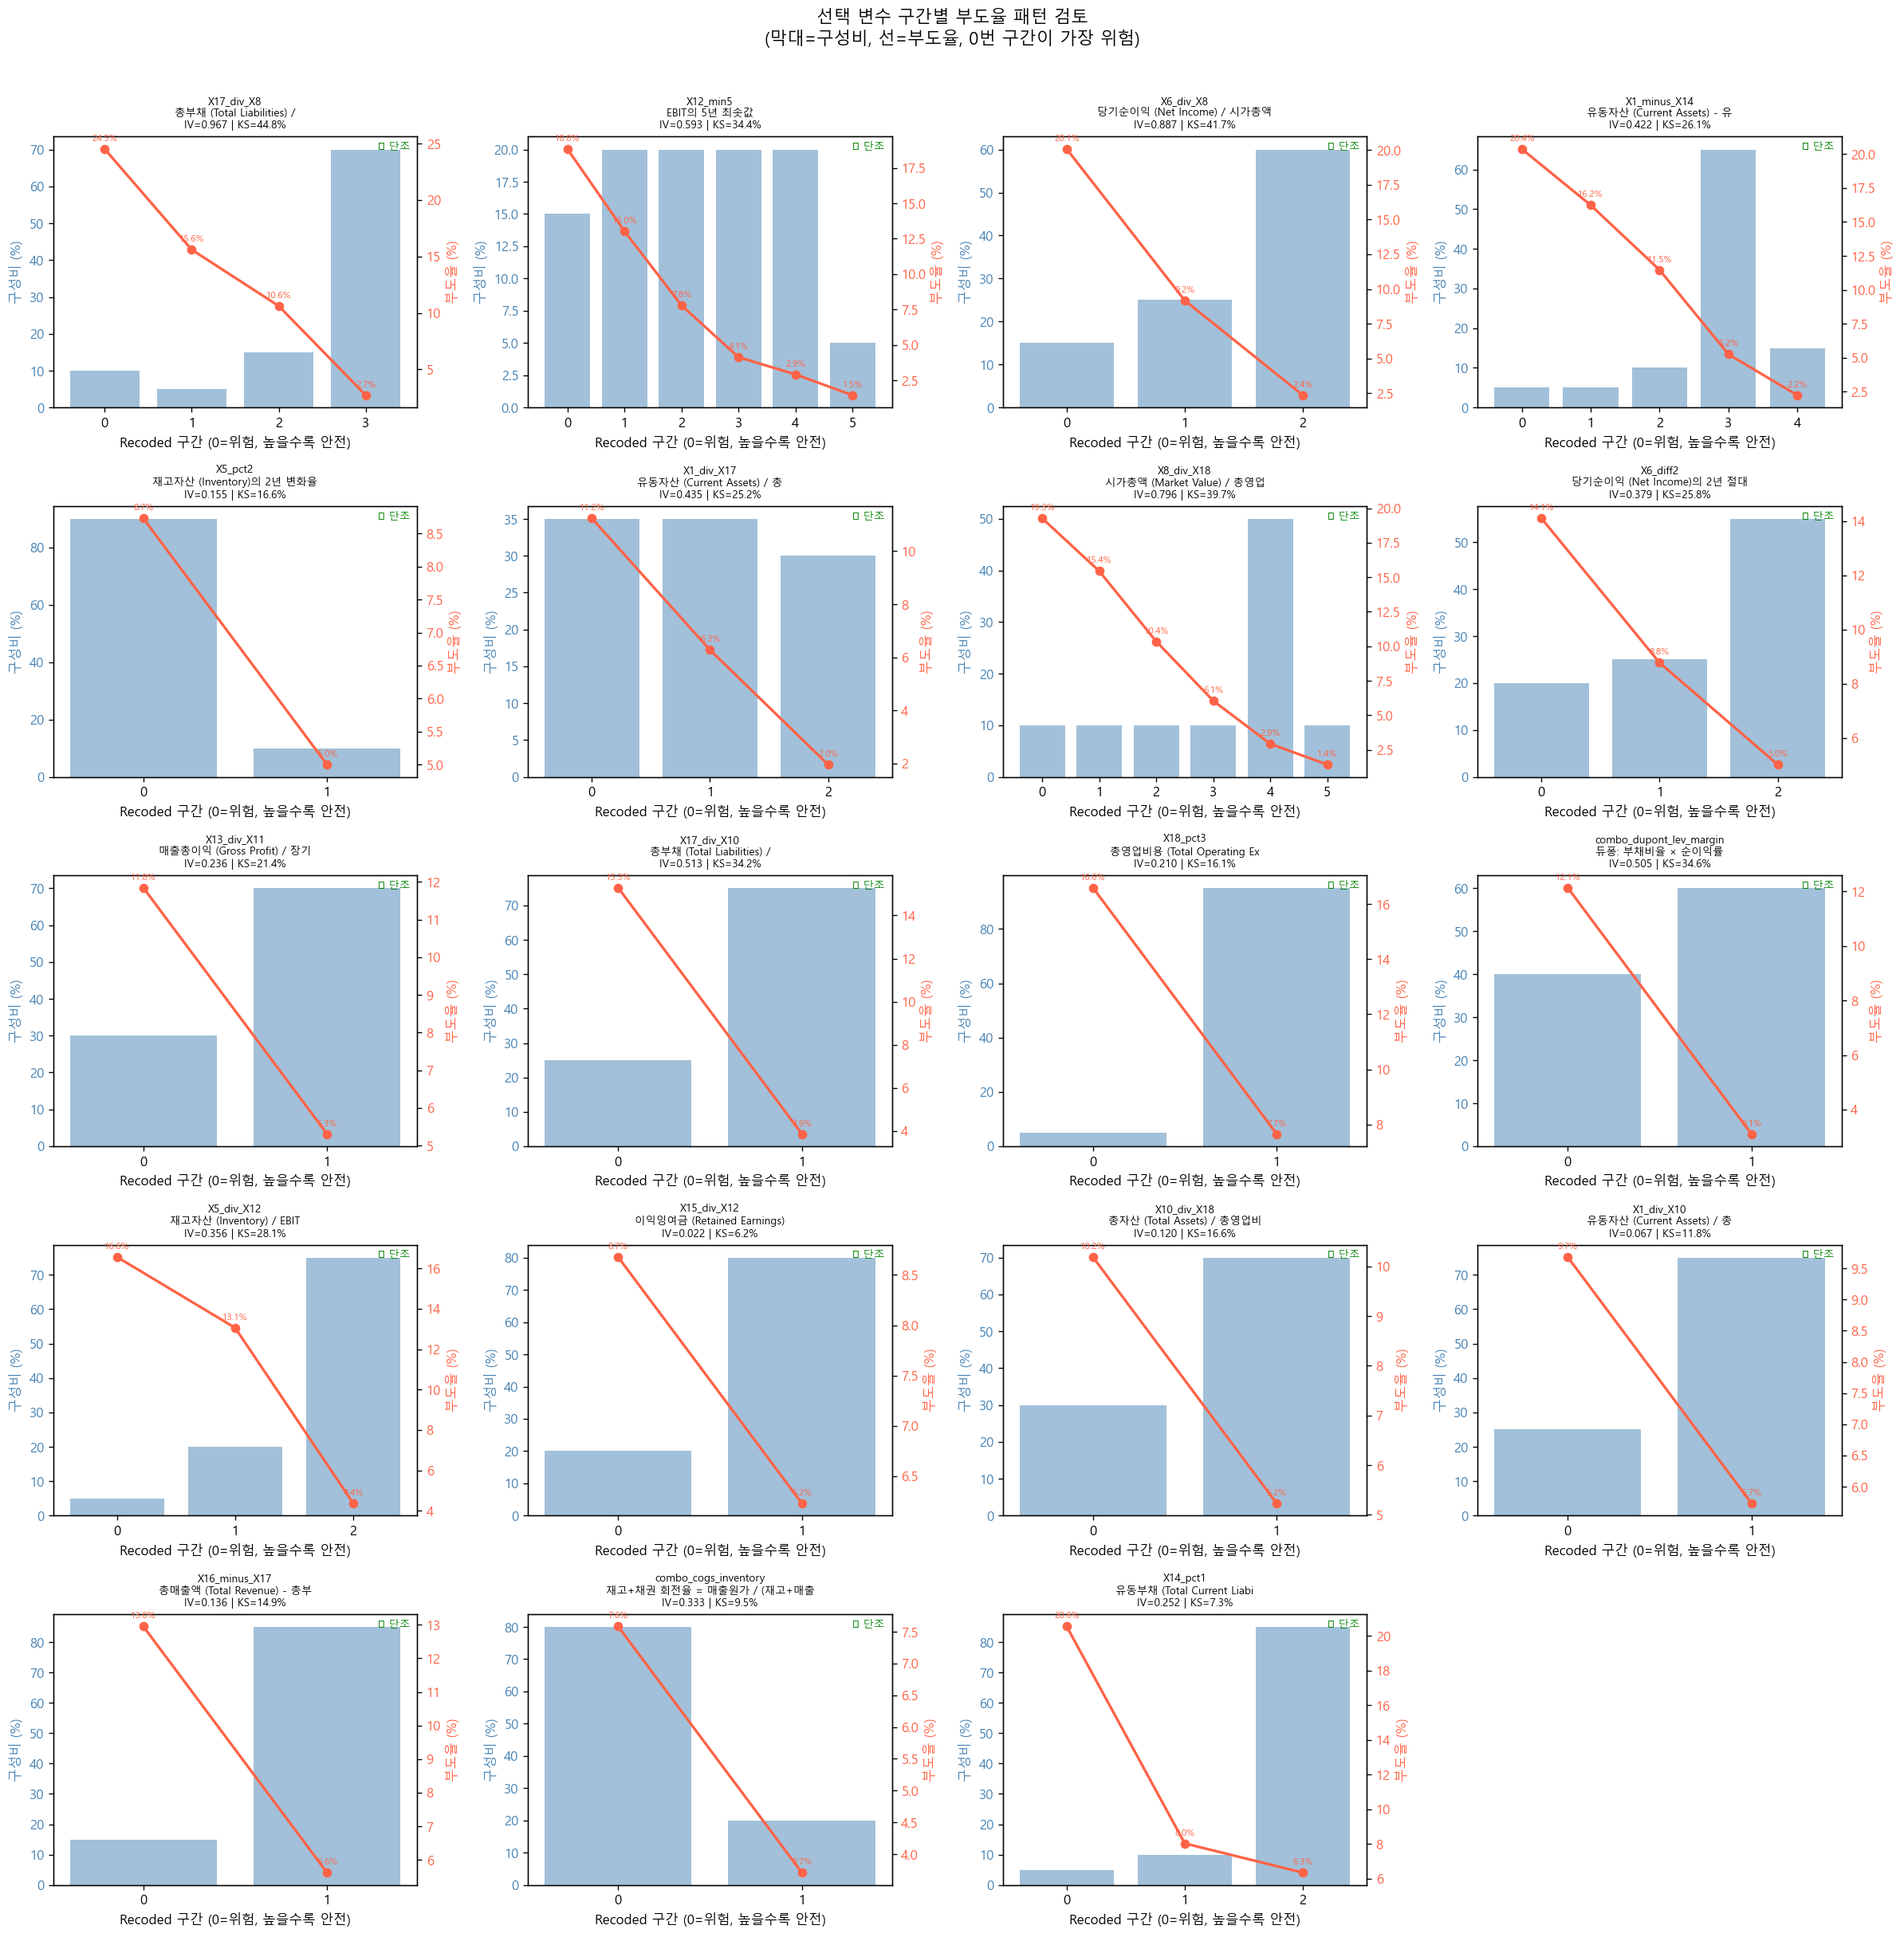

selected_vars 변수 수: 19개
    1. X17_div_X8
    2. X12_min5
    3. X6_div_X8
    4. X1_minus_X14
    5. X5_pct2
    6. X1_div_X17
    7. X8_div_X18
    8. X6_diff2
    9. X13_div_X11
   10. X17_div_X10
   11. X18_pct3
   12. combo_dupont_lev_margin
   13. X5_div_X12
   14. X15_div_X12
   15. X10_div_X18
   16. X1_div_X10
   17. X16_minus_X17
   18. combo_cogs_inventory
   19. X14_pct1
  최종 변수 확정
  Forward Selection :  19개
  수동 제거          :   4개
  최종 확정 변수     :  15개

  수동 제거 변수:
    - X15_div_X12                         | 이익잉여금 (Retained Earnings) / EBIT
    - combo_cogs_inventory                | 재고+채권 회전율 = 매출원가 / (재고+매출채권)
    - X14_pct1                            | 유동부채 (Total Current Liabilities)의 전년대비 변화율
    - X1_div_X10                          | 유동자산 (Current Assets) / 총자산 (Total Assets)

  최종 확정 변수 목록:
    # | 변수명                                 |      IV |      KS | 설명
  -------------------------------------------------------------------------------------
    1 | X17_div_X8  

In [43]:
# ============================================================
# Cell 13. 업무적 판단 - 변수 시각화 검토
#
# [작업 개요]
# Forward Selection으로 선택된 변수들을
# 시각화로 검토
# → 각 변수의 구간별 부도율 패턴 확인
# → 단조성, 변별력, 재무적 해석 가능성 검토
#
# [논문 근거 - 김종윤(2019)]
# p.32 "모형에 반영된 설명변수들과 회귀계수가
#       합리적으로 설명이 가능한지를 종합적으로
#       고려해 최종 모형을 결정한다"
# ============================================================

import math

n_vars  = len(selected_vars)
n_cols  = 4
n_rows  = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(selected_vars):
    ax = axes[i]

    # Train 기준 구간별 부도율 계산
    tmp = pd.DataFrame({
        'recoded'  : recoded_train[col],
        TARGET_COL : recoded_train[TARGET_COL]
    })

    # -1(NaN 구간) 제외
    tmp = tmp[tmp['recoded'] >= 0]

    stats = tmp.groupby('recoded')[TARGET_COL].agg(
        ['sum', 'count'])
    stats.columns  = ['bad', 'count']
    stats['bad_rate'] = stats['bad'] / stats['count'] * 100
    stats['pct']      = stats['count'] / stats['count'].sum() * 100

    bins    = stats.index.astype(int).tolist()
    bad_rates = stats['bad_rate'].tolist()
    pcts      = stats['pct'].tolist()

    # 막대그래프: 구성비
    bars = ax.bar(bins, pcts,
                  color='steelblue', alpha=0.5,
                  label='구성비(%)')
    ax.set_ylabel('구성비 (%)', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')

    # 꺾은선: 부도율
    ax2 = ax.twinx()
    ax2.plot(bins, bad_rates,
             color='tomato', marker='o',
             linewidth=2, label='부도율(%)')
    ax2.set_ylabel('부도율 (%)', color='tomato')
    ax2.tick_params(axis='y', labelcolor='tomato')

    # 부도율 값 표시
    for x, y in zip(bins, bad_rates):
        ax2.annotate(f'{y:.1f}%',
                     xy=(x, y),
                     xytext=(0, 6),
                     textcoords='offset points',
                     ha='center', fontsize=7,
                     color='tomato')

    # 제목
    iv  = iv_summary.get(col, 0)
    ks  = coarse_results[col][2]
    desc = feat_dict[feat_dict['변수명'] == col]['설명'].values
    desc = desc[0][:25] if len(desc) > 0 else ''

    ax.set_title(f"{col}\n{desc}\nIV={iv:.3f} | KS={ks:.1f}%",
                 fontsize=8)
    ax.set_xlabel('Recoded 구간 (0=위험, 높을수록 안전)')
    ax.set_xticks(bins)

    # 단조성 확인
    is_mono = all(bad_rates[j] >= bad_rates[j+1]
                  for j in range(len(bad_rates)-1)) or \
              all(bad_rates[j] <= bad_rates[j+1]
                  for j in range(len(bad_rates)-1))
    mono_txt = '✅ 단조' if is_mono else '⚠️ 비단조'
    ax.text(0.98, 0.98, mono_txt,
            transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            color='green' if is_mono else 'red')

# 빈 subplot 숨기기
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('선택 변수 구간별 부도율 패턴 검토\n'
             '(막대=구성비, 선=부도율, 0번 구간이 가장 위험)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"selected_vars 변수 수: {len(selected_vars)}개")
for i, v in enumerate(selected_vars, 1):
    print(f"  {i:>3}. {v}")

# ============================================================
# Cell 13 하단 추가. 업무적 판단 - 최종 변수 확정
#
# [제거 근거 - 논문 p.32]
# "모형에 반영된 설명변수들과 회귀계수가
#  합리적으로 설명이 가능한지를 종합적으로 고려"
#
# [제거 변수 및 근거]
# X15_div_X12      : IV 0.022, 실무기준 예측력 없음 구간
# combo_cogs_inventory : KS 9.5%, Fine Classing 기준(10%) 미달 수준
# X14_pct1         : KS 7.3%, 변별력 약함
# X1_div_X10       : IV 0.067, 예측력 낮음
#
# [유지 변수 - 제거 불가 근거]
# X16_minus_X17    : X9_minus_X17과 동일 정보이나
#                    X9_minus_X17은 이미 상관분석에서 제거됨
#                    → 현재 설명변수 간 중복 없음 → 유지
# ============================================================

manual_remove = [
    'X15_div_X12',          # IV 0.022, 실무기준 예측력 없음
    'combo_cogs_inventory', # KS 9.5%, 변별력 약함
    'X14_pct1',             # KS 7.3%, 변별력 약함
    'X1_div_X10',           # IV 0.067, 예측력 낮음
]

final_vars = [v for v in selected_vars
              if v not in manual_remove]

print("=" * 60)
print("  최종 변수 확정")
print("=" * 60)
print(f"  Forward Selection : {len(selected_vars):>3}개")
print(f"  수동 제거          : {len(manual_remove):>3}개")
print(f"  최종 확정 변수     : {len(final_vars):>3}개")
print()
print("  수동 제거 변수:")
for v in manual_remove:
    desc = feat_dict[feat_dict['변수명']==v]['설명'].values
    desc = desc[0] if len(desc) > 0 else ''
    print(f"    - {v:<35} | {desc}")
print()
print("  최종 확정 변수 목록:")
print(f"  {'#':>3} | {'변수명':<35} | {'IV':>7} | {'KS':>7} | 설명")
print("  " + "-" * 85)
for i, col in enumerate(final_vars, 1):
    iv   = iv_summary.get(col, 0)
    ks   = coarse_results[col][2]
    desc = feat_dict[feat_dict['변수명']==col]['설명'].values
    desc = desc[0] if len(desc) > 0 else ''
    print(f"  {i:>3} | {col:<35} | {iv:>7.4f} | {ks:>6.2f}% | {desc}")
print()
print("  ※ final_vars 확정 → Cell 14 평점표 구성으로 진행")

In [45]:
# ============================================================
# Cell 14. 평점표 구성
#
# [작업 개요]
# 최종 확정된 15개 변수의 로지스틱 회귀계수를
# 배점(점수) 형태로 변환하여 평점표 구성
#
# [논문 근거 - 김종윤(2019)]
# p.32 "최종 모형이 결정되면 모형의 회귀계수를
#       활용해 신용평점을 생성한다"
# p.32 "불량고객 1명 대비 우량고객 1명이 되는
#       기본점수를 정하고, 일정 점수구간(PDO)만큼
#       증가할 때마다 오즈비율이 두 배가 되도록 설정"
#
# [평점 설계 기준]
# 기본점수(Base Score) : 500점
# PDO(Point to Double Odds) : 40점
# → 오즈가 2배 될 때마다 40점 증가
# → 점수 높을수록 우량 (부도 위험 낮음)
#
# [배점 산출 공식]
# Factor  = PDO / ln(2)
# Offset  = Base - Factor × ln(Odds_0)
# 배점    = -Factor × 회귀계수
# 기본점수 = Offset - Factor × 절편
# ============================================================

# ── 최종 모형 재적합 ─────────────────────────────────────────
# final_vars 15개로 최종 모형 적합
print("  최종 모형 재적합 중...")

final_dummy_list2 = []
for v in final_vars:
    final_dummy_list2.extend(
        feature_to_dummies_final.get(v, []))

X_final2       = X_train[final_dummy_list2].astype(float)
X_final2_const = sm.add_constant(X_final2)

final_model2  = sm.Logit(y_train, X_final2_const)
final_result2 = final_model2.fit(
    method='lbfgs', maxiter=1000, disp=False)

print("  완료")
print()

# ── 평점 설계 파라미터 ───────────────────────────────────────
BASE_SCORE = 500   # 기본점수
PDO        = 40    # Point to Double Odds
ODDS_0     = 1.0   # 기준 오즈 (우량:불량 = 1:1)

Factor = PDO / np.log(2)
Offset = BASE_SCORE - Factor * np.log(ODDS_0)

print(f"  평점 설계 파라미터")
print(f"  기본점수(Base) : {BASE_SCORE}점")
print(f"  PDO            : {PDO}점")
print(f"  Factor         : {Factor:.4f}")
print(f"  Offset         : {Offset:.4f}")
print()

# ── 평점표 구성 ──────────────────────────────────────────────
params_final2 = final_result2.params
intercept     = params_final2.get('const', 0)

# 기본점수 = Offset - Factor × 절편
base_points = Offset - Factor * intercept

scorecard_rows = []

for col in final_vars:
    dummy_cols = feature_to_dummies_final.get(col, [])
    desc       = feat_dict[feat_dict['변수명']==col]['설명'].values
    desc       = desc[0] if len(desc) > 0 else ''

    # 구간별 부도율 계산 (Train 기준)
    tmp = pd.DataFrame({
        'recoded'  : recoded_train[col],
        TARGET_COL : recoded_train[TARGET_COL]
    })
    stats = tmp[tmp['recoded'] >= 0].groupby('recoded')[
        TARGET_COL].agg(['sum','count'])
    stats.columns     = ['bad', 'count']
    stats['bad_rate'] = stats['bad'] / stats['count'] * 100
    stats['pct']      = stats['count'] / stats['count'].sum() * 100

    for d in dummy_cols:
        if d not in params_final2.index:
            continue

        coef   = params_final2[d]
        pval   = final_result2.pvalues[d]
        points = round(Factor * coef)

        # 더미컬럼명에서 구간 번호 추출
        bin_num = int(d.split('_')[-1])

        # 해당 구간 통계
        if bin_num in stats.index:
            bad_rate = stats.loc[bin_num, 'bad_rate']
            pct      = stats.loc[bin_num, 'pct']
            n_count  = stats.loc[bin_num, 'count']
        else:
            bad_rate = np.nan
            pct      = np.nan
            n_count  = 0

        scorecard_rows.append({
            '변수명'    : col,
            '설명'      : desc[:30],
            '더미컬럼'  : d,
            '구간'      : bin_num,
            '회귀계수'  : round(coef, 4),
            '배점'      : points,
            'p값'       : round(pval, 4),
            '부도율(%)'  : round(bad_rate, 2),
            '구성비(%)'  : round(pct, 2),
            '건수'      : n_count,
        })

scorecard_df = pd.DataFrame(scorecard_rows)

# ── 결과 출력 ────────────────────────────────────────────────
print("=" * 70)
print("  평점표 구성 결과")
print("=" * 70)
print(f"  기본점수        : {base_points:.1f}점")
print(f"  최종 변수 수    : {len(final_vars)}개")
print(f"  총 더미컬럼 수  : {len(scorecard_df)}개")
print()

print(f"  {'변수명':<30} | {'구간':>4} | {'회귀계수':>8} | "
      f"{'배점':>6} | {'부도율':>7} | {'구성비':>7} | {'p값':>8}")
print("  " + "-" * 85)

for col in final_vars:
    sub = scorecard_df[scorecard_df['변수명'] == col]
    for _, row in sub.iterrows():
        print(f"  {row['변수명']:<30} | {int(row['구간']):>4} | "
              f"{row['회귀계수']:>8.4f} | {int(row['배점']):>6} | "
              f"{row['부도율(%)']:>6.2f}% | {row['구성비(%)']:>6.2f}% | "
              f"{row['p값']:>8.4f}")
    print("  " + "-" * 85)

print()
print(f"  기본점수 : {base_points:.1f}점")
print(f"  ※ 최종 점수 = 기본점수 + 각 구간 배점의 합")
print(f"  ※ 점수 높을수록 우량 (부도 위험 낮음)")
print(f"  ※ scorecard_df 저장 완료 → Cell 15 모형 검증으로 진행")

  최종 모형 재적합 중...
  완료

  평점 설계 파라미터
  기본점수(Base) : 500점
  PDO            : 40점
  Factor         : 57.7078
  Offset         : 500.0000

  평점표 구성 결과
  기본점수        : 935.2점
  최종 변수 수    : 15개
  총 더미컬럼 수  : 32개

  변수명                            |   구간 |     회귀계수 |     배점 |     부도율 |     구성비 |       p값
  -------------------------------------------------------------------------------------
  X17_div_X8                     |    0 |   0.7268 |     42 |  24.52% |  10.00% |   0.0128
  X17_div_X8                     |    1 |   0.3558 |     21 |  15.61% |   5.00% |   0.1765
  X17_div_X8                     |    2 |   0.3876 |     22 |  10.62% |  15.00% |   0.0410
  -------------------------------------------------------------------------------------
  X12_min5                       |    0 |   1.8035 |    104 |  18.83% |  15.00% |   0.0000
  X12_min5                       |    1 |   1.3851 |     80 |  13.03% |  20.00% |   0.0000
  X12_min5                       |    2 |   0.7686 |     44 |   7.80% 

  점수 산출 중...
  완료

  [1] 점수 분포 요약
  구분           |       평균 |       최소 |       최대 |     표준편차
  -------------------------------------------------------
  Train        |   1160.0 |    935.2 |   1503.2 |     90.8
  Hold-Out     |   1156.6 |    957.2 |   1451.2 |     97.9
  OOT          |   1151.8 |    935.2 |   1498.2 |     91.7

  [2] 우량/불량 점수 분포 비교 (Train)
  구분         |       평균 |      중앙값 |       최소 |       최대
  ----------------------------------------------------
  우량(0)      |   1150.8 |   1143.2 |    935.2 |   1457.2
  불량(1)      |   1287.1 |   1292.2 |    984.2 |   1503.2

  [3] 변별력 검증
  [기준] KS ≥ 20, AR ≥ 30
  [출처] NICE평가정보 기업평가등급체계 성능지표
  구분           |       KS |       AR |       KS판단 |       AR판단
  ----------------------------------------------------------
  Train        |   57.88% |   72.48% |       ✅ 충족 |       ✅ 충족
  Hold-Out     |   60.03% |   76.72% |       ✅ 충족 |       ✅ 충족
  OOT          |   49.38% |   61.58% |       ✅ 충족 |       ✅ 충족

  [4] 안정성 검증 (PSI)
  [기준] PSI < 0.

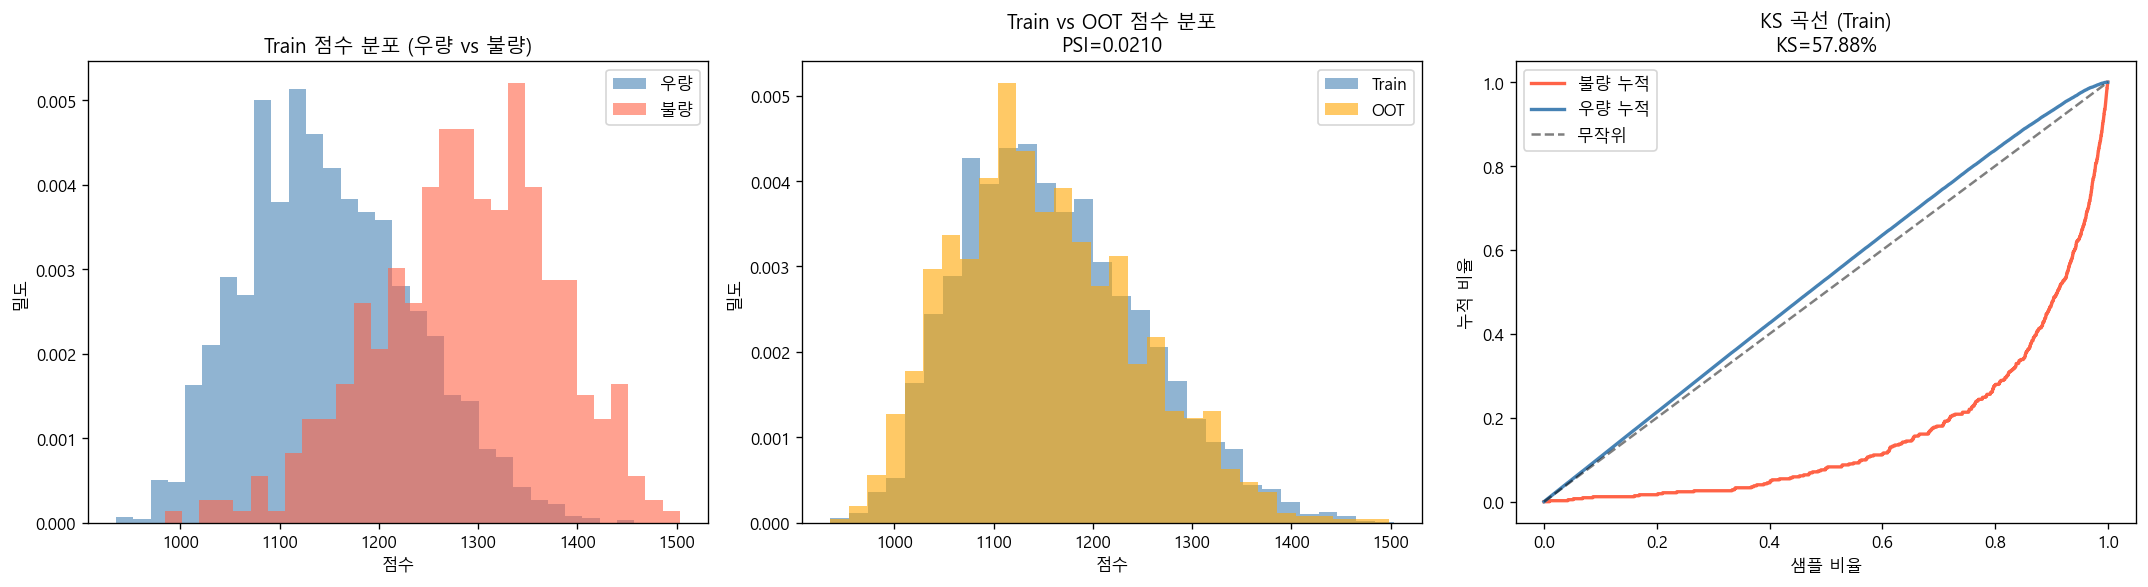

  점수 산출 중...
  완료

  [1] 점수 분포 요약
  구분           |       평균 |       최소 |       최대 |     표준편차
  ----------------------------------------------------
  Train        |   1160.0 |    935.2 |   1503.2 |     90.8
  Hold-Out     |   1156.6 |    957.2 |   1451.2 |     97.9
  OOT          |   1151.8 |    935.2 |   1498.2 |     91.7

  [2] 우량/불량 점수 분포 비교 (Train)
  구분         |       평균 |      중앙값 |       최소 |       최대
  ------------------------------------------------
  우량(0)      |   1150.8 |   1143.2 |    935.2 |   1457.2
  불량(1)      |   1287.1 |   1292.2 |    984.2 |   1503.2

  [3] 변별력 검증 (KS, AR)
  구분           |       KS |       AR |       KS판단 |       AR판단
  -------------------------------------------------------
  Train        |   57.88% |   72.48% |       ✅ 충족 |       ✅ 충족
  Hold-Out     |   60.03% |   76.72% |       ✅ 충족 |       ✅ 충족
  OOT          |   49.38% |   61.58% |       ✅ 충족 |       ✅ 충족

  NICE 기준: KS ≥ 20%, AR ≥ 30%

  [4] 안정성 검증 (PSI)
  Train vs HO     | PSI = 0.0342 | ✅ 안정

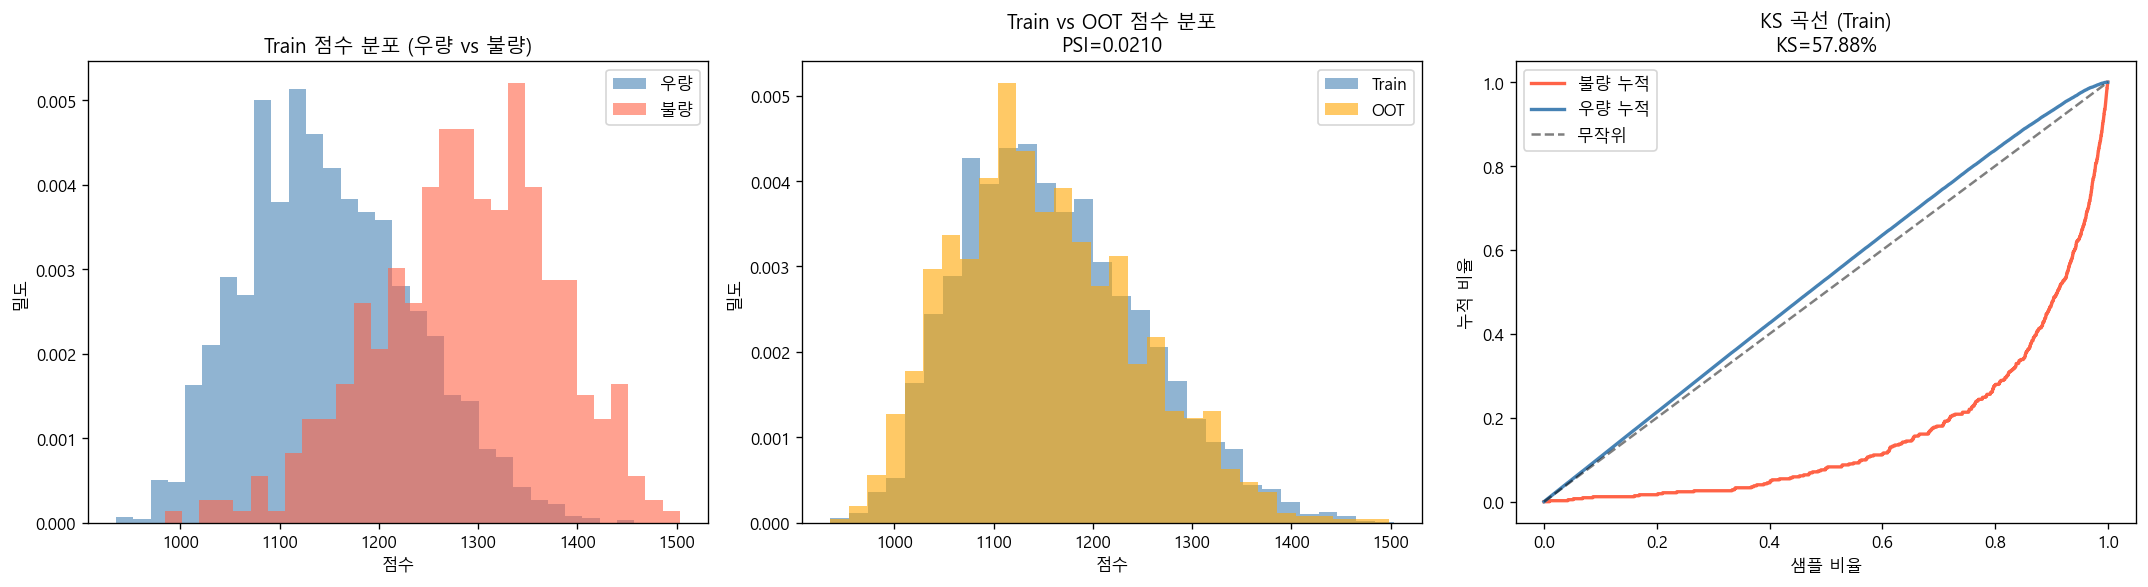

In [47]:
# ============================================================
# Cell 15. 모형 검증 - 점수 산출 및 분포 확인
#
# [작업 개요]
# 평점표 기반으로 Train/Hold-Out/OOT 점수 산출
# 점수 분포 확인 후 등급화 기준 설정
#
# [논문 근거 - 김종윤(2019)]
# p.33 "평점표 구성이 완료되면 개발 모형이
#       실제 업무적으로 활용 가능한 수준까지
#       안정적이고 변별력이 있는지 판단하며
#       최종 모형을 결정"
# p.34 "안정성 검증: PSI ≤ 0.15"
# p.35 "변별력 검증: KS ≥ 40%, AUROC ≥ 70%"
#
# [NICE 공시 기준]# ============================================================
# Cell 15. 모형 검증 - 점수 산출 및 분포 확인
#
# [작업 개요]
# 평점표 기반으로 Train/Hold-Out/OOT 점수 산출
# 점수 분포 확인 후 등급화 기준 설정
#
# [논문 근거 - 김종윤(2019)]
# p.33 "평점표 구성이 완료되면 개발 모형이
#       실제 업무적으로 활용 가능한 수준까지
#       안정적이고 변별력이 있는지 판단하며
#       최종 모형을 결정"
#
# [NICE평가정보 기업평가등급체계 성능지표 기준]
# 출처: niceinfo.co.kr/creditrating/bi_score_2.nice
# 변별력 - KS  : 20 이상
# 변별력 - AR  : 30 이상
# 안정성 - PSI : 0.3 미만
# ============================================================

KS_THRESHOLD  = 20
AR_THRESHOLD  = 30
PSI_THRESHOLD = 0.3

# ── 점수 산출 함수 ───────────────────────────────────────────
def calc_score(recoded_df, scorecard_df, base_points):
    scores = pd.Series(base_points, index=recoded_df.index,
                       dtype=float)
    for col in final_vars:
        sub         = scorecard_df[scorecard_df['변수명'] == col]
        recoded_col = recoded_df[col].astype(float)
        for _, row in sub.iterrows():
            bin_num       = int(row['구간'])
            points        = row['배점']
            mask          = recoded_col == bin_num
            scores[mask] += points
    return scores

# ── 점수 산출 ────────────────────────────────────────────────
print("  점수 산출 중...")
score_train   = calc_score(recoded_train,   scorecard_df, base_points)
score_holdout = calc_score(recoded_holdout, scorecard_df, base_points)
score_oot     = calc_score(recoded_oot,     scorecard_df, base_points)
print("  완료")
print()

# ── 점수 분포 요약 ───────────────────────────────────────────
print("=" * 60)
print("  [1] 점수 분포 요약")
print("=" * 60)
print(f"  {'구분':<12} | {'평균':>8} | {'최소':>8} | {'최대':>8} | {'표준편차':>8}")
print("  " + "-" * 55)
for label, scores in [
    ('Train',    score_train),
    ('Hold-Out', score_holdout),
    ('OOT',      score_oot),
]:
    print(f"  {label:<12} | {scores.mean():>8.1f} | "
          f"{scores.min():>8.1f} | {scores.max():>8.1f} | "
          f"{scores.std():>8.1f}")
print()

# ── 우량/불량 점수 비교 ──────────────────────────────────────
print("=" * 60)
print("  [2] 우량/불량 점수 분포 비교 (Train)")
print("=" * 60)
y_train_arr = recoded_train[TARGET_COL]
good_scores = score_train[y_train_arr == 0]
bad_scores  = score_train[y_train_arr == 1]

print(f"  {'구분':<10} | {'평균':>8} | {'중앙값':>8} | {'최소':>8} | {'최대':>8}")
print("  " + "-" * 52)
print(f"  {'우량(0)':<10} | {good_scores.mean():>8.1f} | "
      f"{good_scores.median():>8.1f} | "
      f"{good_scores.min():>8.1f} | {good_scores.max():>8.1f}")
print(f"  {'불량(1)':<10} | {bad_scores.mean():>8.1f} | "
      f"{bad_scores.median():>8.1f} | "
      f"{bad_scores.min():>8.1f} | {bad_scores.max():>8.1f}")
print()

# ── KS / AR 계산 함수 ────────────────────────────────────────
def calc_ks(y_true, scores):
    y_true     = np.array(y_true)
    sorted_idx = np.argsort(scores)
    y_sorted   = y_true[sorted_idx]
    total_bad  = y_true.sum()
    total_good = (1 - y_true).sum()
    if total_bad == 0 or total_good == 0:
        return 0.0
    cum_bad  = np.cumsum(y_sorted)   / total_bad
    cum_good = np.cumsum(1-y_sorted) / total_good
    return round(np.max(np.abs(cum_bad - cum_good)) * 100, 2)

def calc_ar(y_true, scores):
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(y_true, scores)
    return round((2 * auc - 1) * 100, 2)

def calc_psi(score_base, score_test, n_bins=10):
    bins = pd.qcut(score_base, q=n_bins,
                   duplicates='drop', retbins=True)[1]
    bins[0]  = -np.inf
    bins[-1] =  np.inf
    def get_dist(scores):
        dist = pd.cut(scores, bins=bins).value_counts(
            ).sort_index() / len(scores)
        return dist.replace(0, 1e-10)
    dist_base = get_dist(score_base)
    dist_test = get_dist(score_test)
    psi = ((dist_test - dist_base) *
           np.log(dist_test / dist_base)).sum()
    return round(psi, 4)

# ── 변별력 검증 ──────────────────────────────────────────────
print("=" * 60)
print("  [3] 변별력 검증")
print("  [기준] KS ≥ 20, AR ≥ 30")
print("  [출처] NICE평가정보 기업평가등급체계 성능지표")
print("=" * 60)
print(f"  {'구분':<12} | {'KS':>8} | {'AR':>8} | {'KS판단':>10} | {'AR판단':>10}")
print("  " + "-" * 58)
for label, scores, y_true in [
    ('Train',    score_train,   recoded_train[TARGET_COL]),
    ('Hold-Out', score_holdout, recoded_holdout[TARGET_COL]),
    ('OOT',      score_oot,     recoded_oot[TARGET_COL]),
]:
    ks       = calc_ks(y_true, scores)
    ar       = calc_ar(y_true, scores)
    ks_judge = '✅ 충족' if ks >= KS_THRESHOLD else '❌ 미충족'
    ar_judge = '✅ 충족' if ar >= AR_THRESHOLD else '❌ 미충족'
    print(f"  {label:<12} | {ks:>7.2f}% | {ar:>7.2f}% | "
          f"{ks_judge:>10} | {ar_judge:>10}")
print()

# ── 안정성 검증 (PSI) ────────────────────────────────────────
print("=" * 60)
print("  [4] 안정성 검증 (PSI)")
print("  [기준] PSI < 0.3")
print("  [출처] NICE평가정보 기업평가등급체계 성능지표")
print("=" * 60)
psi_ho  = calc_psi(score_train, score_holdout)
psi_oot = calc_psi(score_train, score_oot)

for label, psi in [
    ('Train vs HO',  psi_ho),
    ('Train vs OOT', psi_oot)
]:
    if psi < PSI_THRESHOLD:
        judge = '✅ 안정 (PSI < 0.3)'
    else:
        judge = '❌ 불안정 (PSI ≥ 0.3)'
    print(f"  {label:<15} | PSI = {psi:.4f} | {judge}")
print()

# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Train 점수 분포 (우량 vs 불량)
axes[0].hist(good_scores, bins=30, alpha=0.6,
             color='steelblue', label='우량', density=True)
axes[0].hist(bad_scores,  bins=30, alpha=0.6,
             color='tomato',    label='불량', density=True)
axes[0].set_title('Train 점수 분포 (우량 vs 불량)')
axes[0].set_xlabel('점수')
axes[0].set_ylabel('밀도')
axes[0].legend()

# (2) Train vs OOT 점수 분포 (PSI 시각화)
axes[1].hist(score_train, bins=30, alpha=0.6,
             color='steelblue', label='Train', density=True)
axes[1].hist(score_oot,   bins=30, alpha=0.6,
             color='orange',    label='OOT',   density=True)
axes[1].set_title(f'Train vs OOT 점수 분포\nPSI={psi_oot:.4f}')
axes[1].set_xlabel('점수')
axes[1].set_ylabel('밀도')
axes[1].legend()

# (3) KS 곡선 (Train)
y_arr    = np.array(recoded_train[TARGET_COL])
sorted_i = np.argsort(score_train.values)
y_sorted = y_arr[sorted_i]
t_bad    = y_arr.sum()
t_good   = (1 - y_arr).sum()
cum_bad  = np.cumsum(y_sorted)   / t_bad
cum_good = np.cumsum(1-y_sorted) / t_good
x_axis   = np.arange(len(y_sorted)) / len(y_sorted)

axes[2].plot(x_axis, cum_bad,  color='tomato',
             label='불량 누적', linewidth=2)
axes[2].plot(x_axis, cum_good, color='steelblue',
             label='우량 누적', linewidth=2)
axes[2].plot([0,1], [0,1], 'k--', alpha=0.5, label='무작위')
ks_train = calc_ks(recoded_train[TARGET_COL], score_train)
axes[2].set_title(f'KS 곡선 (Train)\nKS={ks_train:.2f}%')
axes[2].set_xlabel('샘플 비율')
axes[2].set_ylabel('누적 비율')
axes[2].legend()

plt.tight_layout()
plt.show()
# 안정성: PSI ≤ 0.15 → 최종모형 선택 가능
# 변별력: KS ≥ 20, AR ≥ 30
# ============================================================

# ── 점수 산출 함수 ───────────────────────────────────────────
def calc_score(recoded_df, scorecard_df, base_points):
    '''
    평점표 기반 점수 산출
    각 변수의 해당 구간 배점을 합산
    '''
    scores = pd.Series(base_points, index=recoded_df.index,
                       dtype=float)

    for col in final_vars:
        sub = scorecard_df[scorecard_df['변수명'] == col]
        if sub.empty:
            continue

        recoded_col = recoded_df[col].astype(float)

        for _, row in sub.iterrows():
            bin_num = int(row['구간'])
            points  = row['배점']
            mask    = recoded_col == bin_num
            scores[mask] += points

    return scores

# ── 점수 산출 ────────────────────────────────────────────────
print("  점수 산출 중...")

score_train   = calc_score(recoded_train,   scorecard_df, base_points)
score_holdout = calc_score(recoded_holdout, scorecard_df, base_points)
score_oot     = calc_score(recoded_oot,     scorecard_df, base_points)

print("  완료")
print()

# ── 점수 분포 확인 ───────────────────────────────────────────
print("=" * 55)
print("  [1] 점수 분포 요약")
print("=" * 55)
print(f"  {'구분':<12} | {'평균':>8} | {'최소':>8} | {'최대':>8} | {'표준편차':>8}")
print("  " + "-" * 52)
for label, scores in [
    ('Train',    score_train),
    ('Hold-Out', score_holdout),
    ('OOT',      score_oot),
]:
    print(f"  {label:<12} | {scores.mean():>8.1f} | "
          f"{scores.min():>8.1f} | {scores.max():>8.1f} | "
          f"{scores.std():>8.1f}")
print()

# ── 우량/불량 점수 분포 비교 ─────────────────────────────────
print("=" * 55)
print("  [2] 우량/불량 점수 분포 비교 (Train)")
print("=" * 55)
y_train_arr = recoded_train[TARGET_COL]
good_scores = score_train[y_train_arr == 0]
bad_scores  = score_train[y_train_arr == 1]

print(f"  {'구분':<10} | {'평균':>8} | {'중앙값':>8} | {'최소':>8} | {'최대':>8}")
print("  " + "-" * 48)
print(f"  {'우량(0)':<10} | {good_scores.mean():>8.1f} | "
      f"{good_scores.median():>8.1f} | "
      f"{good_scores.min():>8.1f} | {good_scores.max():>8.1f}")
print(f"  {'불량(1)':<10} | {bad_scores.mean():>8.1f} | "
      f"{bad_scores.median():>8.1f} | "
      f"{bad_scores.min():>8.1f} | {bad_scores.max():>8.1f}")
print()

# ── KS / AR 계산 ─────────────────────────────────────────────
def calc_ks(y_true, scores):
    y_true   = np.array(y_true)
    sorted_idx = np.argsort(scores)
    y_sorted   = y_true[sorted_idx]
    total_bad  = y_true.sum()
    total_good = (1 - y_true).sum()
    if total_bad == 0 or total_good == 0:
        return 0.0
    cum_bad  = np.cumsum(y_sorted)     / total_bad
    cum_good = np.cumsum(1-y_sorted)   / total_good
    return round(np.max(np.abs(cum_bad - cum_good)) * 100, 2)

def calc_ar(y_true, scores):
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(y_true, scores)
    return round((2 * auc - 1) * 100, 2)

def calc_psi(score_base, score_test, n_bins=10):
    bins = pd.qcut(score_base, q=n_bins,
                   duplicates='drop', retbins=True)[1]
    bins[0]  = -np.inf
    bins[-1] =  np.inf

    def get_dist(scores):
        cut = pd.cut(scores, bins=bins)
        dist = cut.value_counts().sort_index() / len(scores)
        return dist.replace(0, 1e-10)

    dist_base = get_dist(score_base)
    dist_test = get_dist(score_test)
    psi = ((dist_test - dist_base) *
           np.log(dist_test / dist_base)).sum()
    return round(psi, 4)

print("=" * 55)
print("  [3] 변별력 검증 (KS, AR)")
print("=" * 55)
print(f"  {'구분':<12} | {'KS':>8} | {'AR':>8} | {'KS판단':>10} | {'AR판단':>10}")
print("  " + "-" * 55)
for label, scores, y_true in [
    ('Train',    score_train,   recoded_train[TARGET_COL]),
    ('Hold-Out', score_holdout, recoded_holdout[TARGET_COL]),
    ('OOT',      score_oot,     recoded_oot[TARGET_COL]),
]:
    ks = calc_ks(y_true, scores)
    ar = calc_ar(y_true, scores)
    ks_judge = '✅ 충족' if ks >= 20 else '❌ 미충족'
    ar_judge = '✅ 충족' if ar >= 30 else '❌ 미충족'
    print(f"  {label:<12} | {ks:>7.2f}% | {ar:>7.2f}% | "
          f"{ks_judge:>10} | {ar_judge:>10}")
print()
print("  NICE 기준: KS ≥ 20%, AR ≥ 30%")
print()

# ── PSI 검증 ─────────────────────────────────────────────────
print("=" * 55)
print("  [4] 안정성 검증 (PSI)")
print("=" * 55)
psi_ho  = calc_psi(score_train, score_holdout)
psi_oot = calc_psi(score_train, score_oot)

for label, psi in [('Train vs HO', psi_ho),
                   ('Train vs OOT', psi_oot)]:
    if psi <= 0.15:
        judge = '✅ 안정 (PSI ≤ 0.15)'
    elif psi <= 0.25:
        judge = '⚠️ 주의 (0.15 < PSI ≤ 0.25)'
    else:
        judge = '❌ 불안정 (PSI > 0.25)'
    print(f"  {label:<15} | PSI = {psi:.4f} | {judge}")
print()
print("  NICE 기준: PSI ≤ 0.15 → 최종모형 선택 가능")
print()

# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 점수 분포 (우량 vs 불량)
axes[0].hist(good_scores, bins=30, alpha=0.6,
             color='steelblue', label='우량', density=True)
axes[0].hist(bad_scores,  bins=30, alpha=0.6,
             color='tomato',    label='불량', density=True)
axes[0].set_title('Train 점수 분포 (우량 vs 불량)')
axes[0].set_xlabel('점수')
axes[0].set_ylabel('밀도')
axes[0].legend()

# (2) Train vs OOT 점수 분포 (PSI 시각화)
axes[1].hist(score_train, bins=30, alpha=0.6,
             color='steelblue', label='Train', density=True)
axes[1].hist(score_oot,   bins=30, alpha=0.6,
             color='orange',    label='OOT',   density=True)
axes[1].set_title(f'Train vs OOT 점수 분포\nPSI={psi_oot:.4f}')
axes[1].set_xlabel('점수')
axes[1].set_ylabel('밀도')
axes[1].legend()

# (3) KS 곡선
from sklearn.metrics import roc_curve
y_arr    = np.array(recoded_train[TARGET_COL])
sorted_i = np.argsort(score_train.values)
y_sorted = y_arr[sorted_i]
t_bad    = y_arr.sum()
t_good   = (1-y_arr).sum()
cum_bad  = np.cumsum(y_sorted)   / t_bad
cum_good = np.cumsum(1-y_sorted) / t_good
x_axis   = np.arange(len(y_sorted)) / len(y_sorted)

axes[2].plot(x_axis, cum_bad,  color='tomato',
             label='불량 누적', linewidth=2)
axes[2].plot(x_axis, cum_good, color='steelblue',
             label='우량 누적', linewidth=2)
axes[2].plot([0,1], [0,1], 'k--', alpha=0.5, label='무작위')
ks_train = calc_ks(recoded_train[TARGET_COL], score_train)
axes[2].set_title(f'KS 곡선 (Train)\nKS={ks_train:.2f}%')
axes[2].set_xlabel('샘플 비율')
axes[2].set_ylabel('누적 비율')
axes[2].legend()

plt.tight_layout()
plt.show()